# 1. Importing Necessary Libaries

In [64]:
import torch
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import ExtraTreesRegressor
import torch.nn as nn
import matplotlib.pyplot as plt
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


# 2 Load Data set

Loding the dataset before EDA and for data understanding

In [65]:
import kagglehub
path = kagglehub.dataset_download("uditjain13/ai-and-data-science-job-salaries-2026")
print("Path to dataset files:", path)


Using Colab cache for faster access to the 'ai-and-data-science-job-salaries-2026' dataset.
Path to dataset files: /kaggle/input/ai-and-data-science-job-salaries-2026


In [66]:
# df = pd.read_csv("/kaggle/input/datasets/uditjain13/ai-and-data-science-job-salaries-2026/ai_ds_job_salaries_2026.csv")
df = pd.read_csv("/kaggle/input/ai-and-data-science-job-salaries-2026/ai_ds_job_salaries_2026.csv") #colab
df.head(5)

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,...,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
0,Data Analyst,Lead,Part-time,S,IN,AU,Finance,0,14.4,Bachelors,...,12.5,INR,23844,0.505,11.6,5.5,8,True,2.2,7.4
1,Research Scientist,Senior,Full-time,L,US,US,Retail,50,7.6,Masters,...,2.1,USD,170132,0.054,2.9,7.0,3,False,8.2,5.3
2,Machine Learning Engineer,Entry,Full-time,M,US,US,Government,0,0.0,Bootcamp,...,5.1,USD,83059,0.191,7.5,5.9,1,False,2.8,6.8
3,Data Engineer,Senior,Full-time,M,BR,IN,Government,100,9.7,Masters,...,2.0,BRL,29531,0.102,9.3,5.6,5,False,7.8,5.0
4,Data Engineer,Mid,Full-time,M,US,US,Education,0,3.2,Bachelors,...,4.0,USD,70105,0.064,10.6,4.6,4,False,9.1,5.1


In [67]:
df.tail(5)

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,...,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
4995,Data Analyst,Mid,Full-time,M,PL,PL,Finance,50,9.3,Masters,...,1.5,PLN,38810,0.182,12.0,7.3,2,False,7.8,4.8
4996,Machine Learning Engineer,Lead,Full-time,M,ES,ES,Technology,0,13.3,Self-taught,...,2.6,EUR,123368,0.000,11.0,5.5,7,False,4.0,1.3
4997,Data Science Manager,Senior,Full-time,M,PL,PL,Technology,50,8.1,Bachelors,...,9.7,PLN,86123,0.078,13.3,7.0,6,True,19.2,2.7
4998,Research Scientist,Senior,Freelance,M,PL,PL,Technology,0,12.9,Bachelors,...,10.7,PLN,76001,0.122,10.1,6.0,4,True,10.8,1.5
4999,Business Intelligence Analyst,Entry,Contract,M,US,US,Government,0,2.1,Masters,...,10.4,USD,49321,0.022,4.8,6.6,3,False,6.9,6.1


# 3 Perform EDA .
To Understand data  we have performing EDA exploratory data analysis EDA

In [68]:
print('DataFrame Info:')
df.info()

print('\nMissing values per column:')
print(df.isnull().sum())

print('\nDescriptive statistics:')
df.describe().T

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_title                   5000 non-null   object 
 1   experience_level            5000 non-null   object 
 2   employment_type             5000 non-null   object 
 3   company_size                5000 non-null   object 
 4   company_location            5000 non-null   object 
 5   employee_residence          5000 non-null   object 
 6   industry                    5000 non-null   object 
 7   remote_ratio                5000 non-null   int64  
 8   years_experience            5000 non-null   float64
 9   education_level             5000 non-null   object 
 10  primary_language            5000 non-null   object 
 11  has_ml_in_title             5000 non-null   bool   
 12  manages_people              5000 non-null   bool   
 13  team_size        

,count,mean,std,min,25%,50%,75%,max
remote_ratio,5000.0,43.08000,41.454280,0.0,0.000,50.000,100.000,100.000
years_experience,5000.0,8.36144,4.820808,0.0,4.800,8.100,11.500,23.700
team_size,5000.0,7.93620,2.647930,1.0,6.000,8.000,10.000,19.000
certifications_count,5000.0,1.82040,1.344212,0.0,1.000,2.000,3.000,8.000
weekly_hours,5000.0,44.34540,6.142761,24.4,40.100,44.400,48.500,67.300
ai_tools_hours_per_week,5000.0,8.43740,5.503637,0.0,3.300,8.500,12.625,25.200
salary_usd,5000.0,98605.40620,55369.310473,12000.0,55592.750,90572.000,129657.750,372347.000
equity_offered_pct,5000.0,0.13902,0.184243,0.0,0.017,0.072,0.175,1.264
bonus_pct,5000.0,10.80272,5.152959,0.0,7.100,10.600,14.200,30.800
job_satisfaction_score,5000.0,6.68532,1.364302,1.1,5.800,6.700,7.600,10.000


In [69]:
df.columns

Index(['job_title', 'experience_level', 'employment_type', 'company_size',
       'company_location', 'employee_residence', 'industry', 'remote_ratio',
       'years_experience', 'education_level', 'primary_language',
       'has_ml_in_title', 'manages_people', 'team_size',
       'certifications_count', 'weekly_hours', 'uses_ai_tools_daily',
       'ai_tools_hours_per_week', 'salary_currency', 'salary_usd',
       'equity_offered_pct', 'bonus_pct', 'job_satisfaction_score',
       'interviews_to_offer', 'switched_jobs_last_year',
       'upskilling_hours_per_month', 'fears_ai_automation_score'],
      dtype='object')

In [70]:
df.isnull().sum()

,0
job_title,0
experience_level,0
employment_type,0
company_size,0
company_location,0
employee_residence,0
industry,0
remote_ratio,0
years_experience,0
education_level,0


In [71]:
print("Dataset shape ",df.shape)
print("Duplicate ",df.duplicated().sum())

Dataset shape  (5000, 27)
Duplicate  0


In [72]:
print("Job Titles:", df['job_title'].nunique())
print(df['job_title'].value_counts())

Job Titles: 12
job_title
Data Scientist                   709
Data Engineer                    682
Data Analyst                     627
Machine Learning Engineer        593
AI Engineer                      506
Analytics Engineer               317
MLOps Engineer                   306
Business Intelligence Analyst    293
Research Scientist               269
LLM Engineer                     242
Data Science Manager             238
Computer Vision Engineer         218
Name: count, dtype: int64


## Salary Distribution


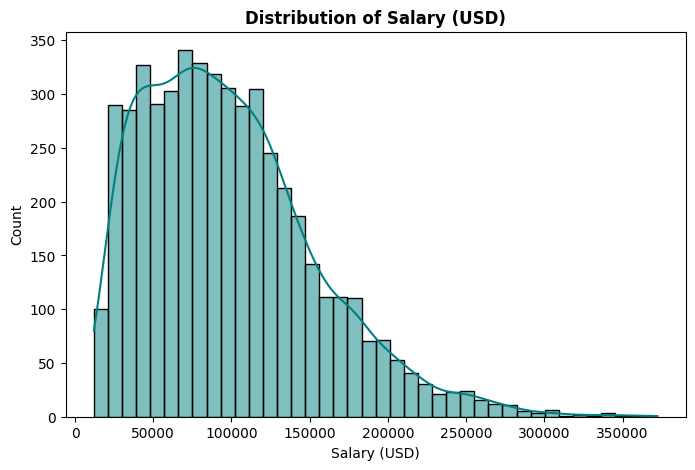

count      5000.000000
mean      98605.406200
std       55369.310473
min       12000.000000
25%       55592.750000
50%       90572.000000
75%      129657.750000
max      372347.000000
Name: salary_usd, dtype: float64


In [73]:
plt.figure(figsize=(8,5))
sns.histplot(df['salary_usd'], bins=40, kde=True, color='teal')
plt.title("Distribution of Salary (USD)",fontweight='bold')
plt.xlabel("Salary (USD)")
plt.show()

print(df['salary_usd'].describe())

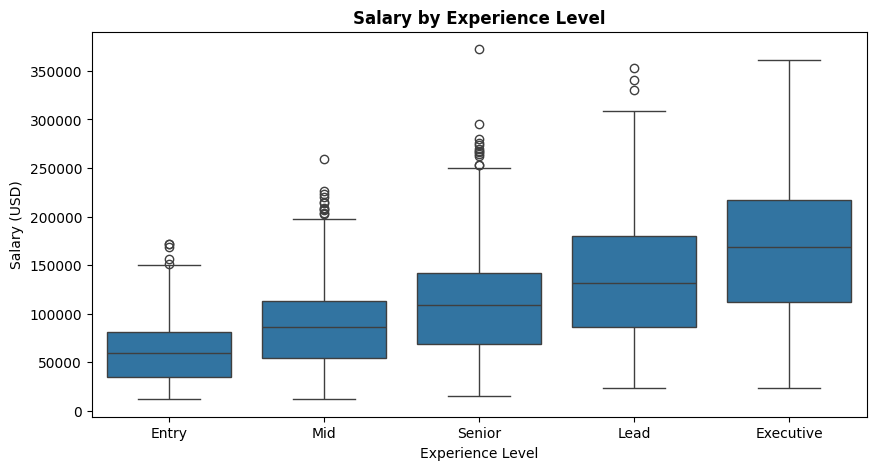

In [74]:
plt.figure(figsize=(10,5))
order = df.groupby('experience_level')['salary_usd'].median().sort_values().index
sns.boxplot(data=df, x='experience_level', y='salary_usd', order=order)
plt.title("Salary by Experience Level",fontweight='bold')
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")
plt.show()

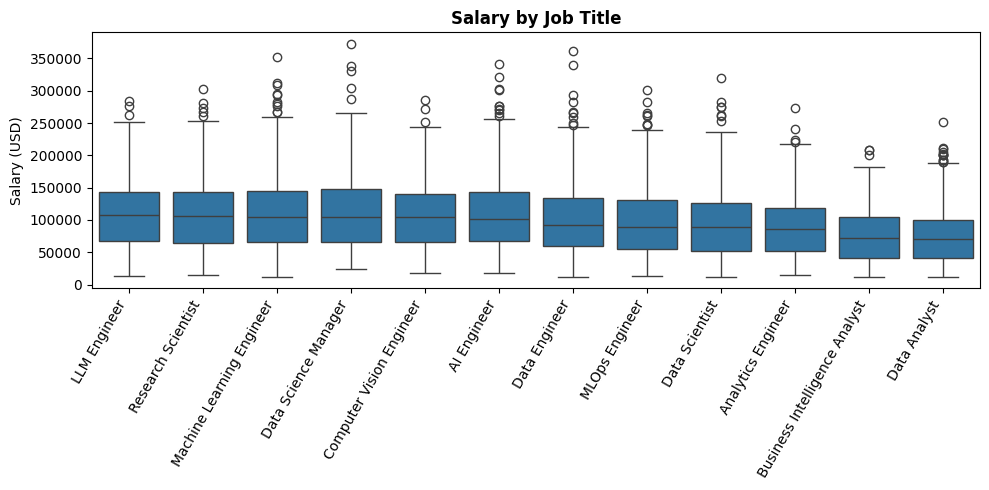

In [75]:
plt.figure(figsize=(10,5))
order = df.groupby('job_title')['salary_usd'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='job_title', y='salary_usd', order=order)
plt.title("Salary by Job Title",fontweight='bold')
plt.xticks(rotation=60, ha='right')
plt.xlabel("")
plt.ylabel("Salary (USD)")
plt.tight_layout()
plt.show()

In [76]:
# Salary Boxplot
fig = px.box(
    df,
    y='salary_usd',
    title='Salary Distribution and Potential Outliers',
    labels={'salary_usd': 'Salary (USD)'}
)

fig.show()

 IQR Calculation
* Calculate IQR for salary
*  Identify potential outliers

In [77]:
Q1 = df['salary_usd'].quantile(0.25)
Q3 = df['salary_usd'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1          : ${Q1:,.2f}")
print(f"Q3          : ${Q3:,.2f}")
print(f"IQR         : ${IQR:,.2f}")
print(f"Lower Bound : ${lower_bound:,.2f}")
print(f"Upper Bound : ${upper_bound:,.2f}")

Q1          : $55,592.75
Q3          : $129,657.75
IQR         : $74,065.00
Lower Bound : $-55,504.75
Upper Bound : $240,755.25


In [78]:
outliers = df[
    (df['salary_usd'] < lower_bound) |
    (df['salary_usd'] > upper_bound)
]

print(f"Potential outliers: {len(outliers)}")
print(f"Percentage: {len(outliers) / len(df) * 100:.2f}%")

Potential outliers: 103
Percentage: 2.06%


In [79]:
outliers.sort_values('salary_usd', ascending=False).head(20)

,job_title,experience_level,employment_type,company_size,company_location,employee_residence,industry,remote_ratio,years_experience,education_level,...,ai_tools_hours_per_week,salary_currency,salary_usd,equity_offered_pct,bonus_pct,job_satisfaction_score,interviews_to_offer,switched_jobs_last_year,upskilling_hours_per_month,fears_ai_automation_score
2935,Data Science Manager,Senior,Full-time,L,US,US,Technology,0,9.2,PhD,...,8.7,USD,372347,0.061,14.8,6.1,1,False,12.9,3.2
3161,Data Engineer,Executive,Full-time,L,US,IN,Retail,100,18.1,Masters,...,10.5,USD,361230,0.013,18.1,6.4,9,False,0.0,7.3
3661,Machine Learning Engineer,Lead,Full-time,L,US,US,Finance,50,15.5,Masters,...,10.7,USD,352584,0.000,14.5,5.9,1,True,6.7,3.8
3983,AI Engineer,Executive,Full-time,L,US,US,Technology,0,20.2,Bachelors,...,7.5,USD,340887,0.114,12.5,9.3,6,False,12.9,4.1
1516,Data Engineer,Lead,Full-time,L,US,US,Technology,0,14.1,Masters,...,0.0,USD,340188,0.030,16.5,5.2,14,False,6.8,5.7
3528,Data Science Manager,Executive,Full-time,M,US,US,Technology,0,22.9,PhD,...,1.0,USD,338452,0.077,16.0,6.0,6,False,6.0,3.7
809,Data Science Manager,Lead,Contract,M,US,US,Finance,100,17.9,PhD,...,3.4,USD,329944,0.138,8.8,7.1,4,False,7.2,2.3
3899,AI Engineer,Executive,Contract,L,AU,AU,Energy,0,18.9,Masters,...,11.0,AUD,321535,0.039,22.2,6.4,1,False,12.2,1.6
1037,Data Scientist,Executive,Full-time,L,US,US,Finance,0,19.7,Masters,...,13.9,USD,320354,0.000,21.9,8.0,9,False,1.0,3.5
3351,Machine Learning Engineer,Executive,Full-time,L,US,US,Consulting,100,19.7,PhD,...,11.6,USD,312050,0.008,23.6,6.3,5,False,8.1,3.0


### Outlier Analysis

The IQR-based analysis identified 103 observations (2.06% of the dataset)
as potential high-salary outliers. The upper bound was approximately
usd 240,USD 755, while the maximum observed salary was approximately usd 372, usd 347.
Since these observations are associated with various legitimate AI and
Data Science job roles, they were not removed automatically. Their impact
will be considered during the preprocessing and modeling stages.

# 4 Feature Audit and Selection

Before building the final preprocessing pipeline, the predictor variables are
reviewed to determine their data types, uniqueness, and missing values. This
step helps identify suitable features for salary prediction and supports the
design of the subsequent data mining and data warehouse components.

In [80]:
# Feature audit summary

feature_audit = pd.DataFrame({
    'Data Type': df.drop(columns=['salary_usd']).dtypes.astype(str),
    'Unique Values': df.drop(columns=['salary_usd']).nunique(),
    'Missing Values': df.drop(columns=['salary_usd']).isnull().sum()
})

feature_audit

,Data Type,Unique Values,Missing Values
job_title,object,12,0
experience_level,object,5,0
employment_type,object,4,0
company_size,object,3,0
company_location,object,12,0
employee_residence,object,12,0
industry,object,10,0
remote_ratio,int64,3,0
years_experience,float64,230,0
education_level,object,5,0


In [81]:
df['salary_currency'].value_counts()

,count
salary_currency,
USD,1786
EUR,867
INR,782
GBP,488
CAD,350
AUD,240
BRL,210
PLN,147
SGD,130


### Checking the relationship between company location and salary currency

In [82]:


currency_location = pd.crosstab(
    df['company_location'],
    df['salary_currency']
)

currency_location

salary_currency,AUD,BRL,CAD,EUR,GBP,INR,PLN,SGD,USD
company_location,,,,,,,,,
AU,240,0,0,0,0,0,0,0,0
BR,0,210,0,0,0,0,0,0,0
CA,0,0,350,0,0,0,0,0,0
DE,0,0,0,350,0,0,0,0,0
ES,0,0,0,128,0,0,0,0,0
FR,0,0,0,189,0,0,0,0,0
GB,0,0,0,0,488,0,0,0,0
IN,0,0,0,0,0,782,0,0,0
NL,0,0,0,200,0,0,0,0,0


### Feature Audit: Salary Currency

The `salary_currency` feature was examined to determine whether it provides
independent information for salary prediction. A cross-tabulation between
`company_location` and `salary_currency` shows a strong one-to-one or
one-to-many geographical correspondence, with currencies largely determined
by the company location.

Since the target variable `salary_usd` is already standardized to US dollars,
the `salary_currency` feature provides limited additional predictive
information and may introduce redundant information alongside
`company_location`. Therefore, `salary_currency` is excluded from the final
predictor set.

In [83]:
# Drop redundant feature

df_model = df.drop(columns=['salary_currency'])

print("Original shape:", df.shape)
print("Shape after removing salary_currency:", df_model.shape)

Original shape: (5000, 27)
Shape after removing salary_currency: (5000, 26)


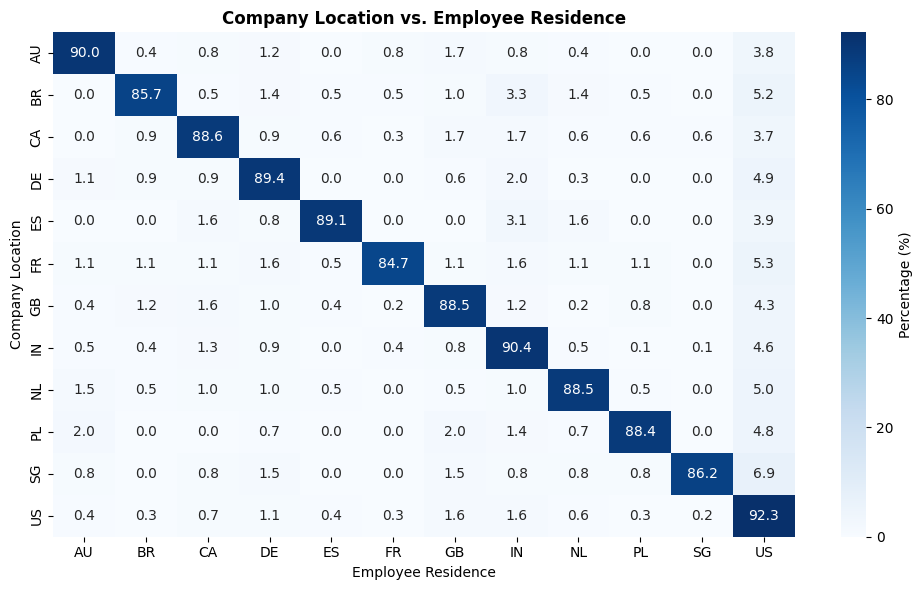

In [84]:
# Compare company location and employee residence using percentages

location_pct = pd.crosstab(
    df['company_location'],
    df['employee_residence'],
    normalize='index'
) * 100

plt.figure(figsize=(10, 6))

sns.heatmap(
    location_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    cbar_kws={'label': 'Percentage (%)'}
)

plt.title(
    'Company Location vs. Employee Residence',
    fontweight='bold'
)

plt.xlabel('Employee Residence')
plt.ylabel('Company Location')
plt.tight_layout()
plt.show()

### Location Feature Analysis

The heatmap shows a strong geographical alignment between company location
and employee residence, with most observations concentrated along the
diagonal. However, the presence of non-diagonal observations indicates that
employees may reside in countries different from their company locations.
Therefore, the two features are considered related but not fully redundant
and are retained for further analysis.

In [85]:
df['remote_ratio'].value_counts().sort_index()

,count
remote_ratio,
0,2112
50,1468
100,1420


### Feature Audit: Remote Work Ratio

The `remote_ratio` feature contains three distinct values: 0, 50, and 100,
representing different levels of remote work. The distribution shows that
all three categories are sufficiently represented in the dataset. Since the
values have a meaningful ordered interpretation as the proportion of remote
work, the feature is retained as a numerical predictor for further analysis.

In [86]:
df['years_experience'].describe()

,years_experience
count,5000.000000
mean,8.361440
std,4.820808
min,0.000000
25%,4.800000
50%,8.100000
75%,11.500000
max,23.700000


In [87]:
# Compare experience level with years of experience

experience_summary = (
    df.groupby('experience_level')['years_experience']
      .agg(['count', 'mean', 'median', 'min', 'max'])
      .sort_values('median')
)

experience_summary

,count,mean,median,min,max
experience_level,,,,,
Entry,985,2.211980,2.10,0.0,7.1
Mid,1613,6.256417,6.30,0.0,11.8
Senior,1520,10.361711,10.40,4.4,17.4
Lead,656,14.476829,14.50,9.5,20.9
Executive,226,18.983186,18.95,14.4,23.7


# 5 Corelation Heatmap -

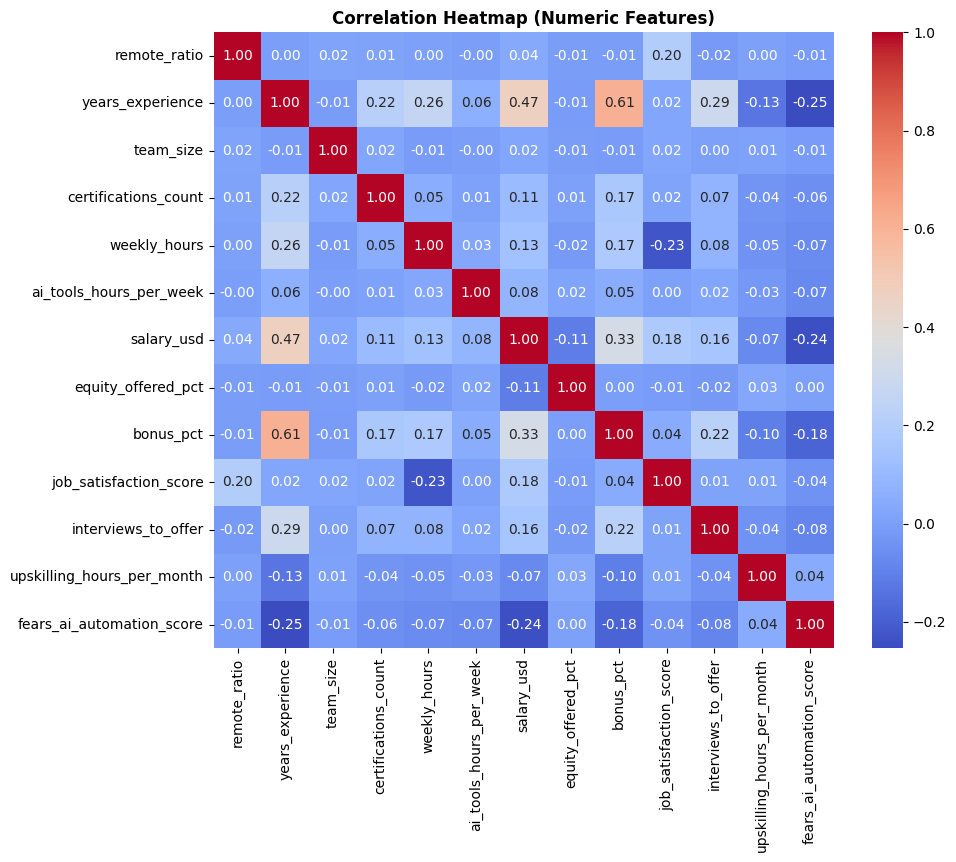

In [88]:
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap (Numeric Features)",fontweight='bold')
plt.show()

# 6 Data Preprocessing


## 6.1 Define target and feature

In [89]:

target = 'salary_usd'

# Remove target and redundant feature
X = df.drop(columns=[target, 'salary_currency'])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (5000, 25)
Target shape: (5000,)


## 6.2 Identify categorical and numerical columns

In [90]:
cat_cols = X.select_dtypes(
    include=['object', 'bool']
).columns.tolist()

num_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

print("Categorical features:")
print(cat_cols)

print("\nNumerical features:")
print(num_cols)

Categorical features:
['job_title', 'experience_level', 'employment_type', 'company_size', 'company_location', 'employee_residence', 'industry', 'education_level', 'primary_language', 'has_ml_in_title', 'manages_people', 'uses_ai_tools_daily', 'switched_jobs_last_year']

Numerical features:
['remote_ratio', 'years_experience', 'team_size', 'certifications_count', 'weekly_hours', 'ai_tools_hours_per_week', 'equity_offered_pct', 'bonus_pct', 'job_satisfaction_score', 'interviews_to_offer', 'upskilling_hours_per_month', 'fears_ai_automation_score']


## 6.3 Train Test split

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (4000, 25)
Testing set: (1000, 25)


## 6.4 Preprocessing Pipeline

In [92]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            cat_cols
        )
    ],
    remainder='passthrough'
)
print("Done")

Done


## 6.7 Final Pre processing Pipeline

In [93]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline


target = 'salary_usd'

X = df.drop(columns=[target, 'salary_currency'])
y = df[target]




cat_cols = X.select_dtypes(
    include=['object', 'bool']
).columns.tolist()

num_cols = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()


print("Number of categorical features:", len(cat_cols))
print("Number of numerical features:", len(num_cols))



X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            cat_cols
        )
    ],
    remainder='passthrough'
)

print("\nTraining set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Number of categorical features: 13
Number of numerical features: 12

Training set: (4000, 25)
Testing set: (1000, 25)
Training target: (4000,)
Testing target: (1000,)


# 7 Model Building

## 7.1 Define Candidate Models

* Linear Regression
* baseline modelRandom Forest
*  ensemble tree modelXGBoost
*  gradient boostingLightGBM
*  gradient boosting
* cat Boost
* Extra Trees


In [94]:
!pip install catboost

In [95]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

models = {

    'Linear Regression': LinearRegression(),

    'Random Forest': RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    'Extra Trees': ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    ),

    'LightGBM': LGBMRegressor(
        n_estimators=400,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ),

    'CatBoost': CatBoostRegressor(
        iterations=400,
        learning_rate=0.05,
        depth=5,
        random_seed=42,
        verbose=False
    )
}

## 7.2 Train and Generate Prediction

In [96]:
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

results = []
fitted_pipelines = {}

for name, model in models.items():

    # Create preprocessing + model pipeline
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train model
    pipe.fit(X_train, y_train)

    # Predict on unseen test data
    preds = pipe.predict(X_test)

    # Evaluation metrics
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    # Store results
    results.append({
        'Model': name,
        'R2 Score': r2,
        'MAE': mae,
        'RMSE': rmse
    })

    # Store fitted pipeline for later analysis
    fitted_pipelines[name] = pipe

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



## 7.3 Tree Vizualization

In [97]:
# Get feature names after preprocessing
feature_names = (
    fitted_pipelines['Random Forest']
    .named_steps['preprocessor']
    .get_feature_names_out()
)

print("Total transformed features:", len(feature_names))

Total transformed features: 90


### 7.3.1 Random Forest Vizualization

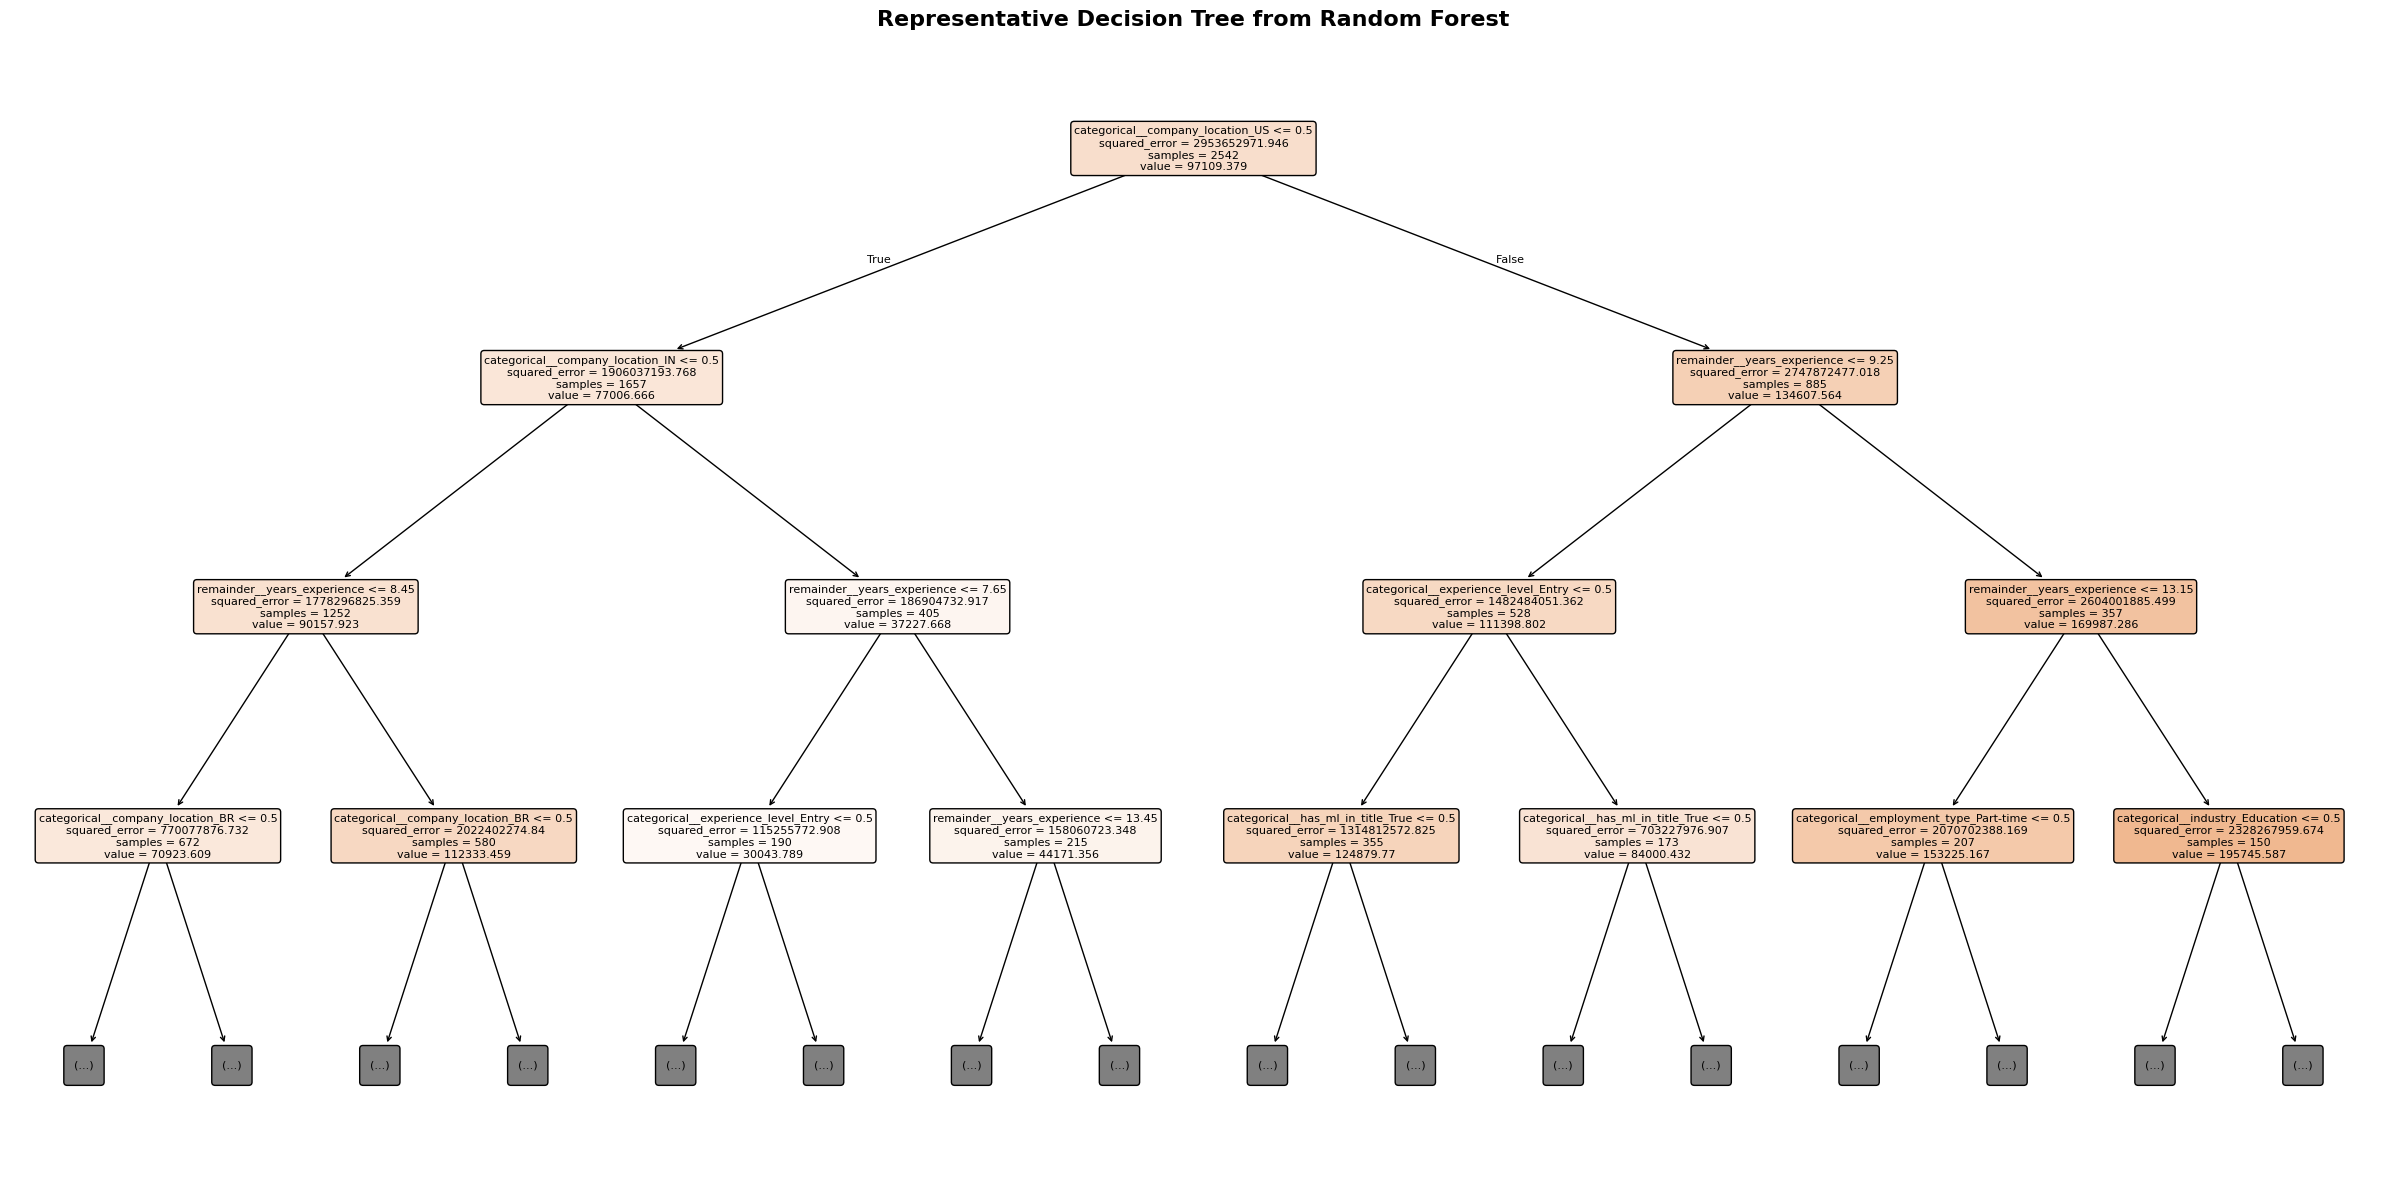

In [98]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Extract trained Random Forest model
rf_model = fitted_pipelines['Random Forest'].named_steps['model']

# Select the first tree
rf_tree = rf_model.estimators_[0]

plt.figure(figsize=(24, 12))

plot_tree(
    rf_tree,
    feature_names=feature_names,
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    "Representative Decision Tree from Random Forest",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### 7.3.2 XGBoost — Representative Tree

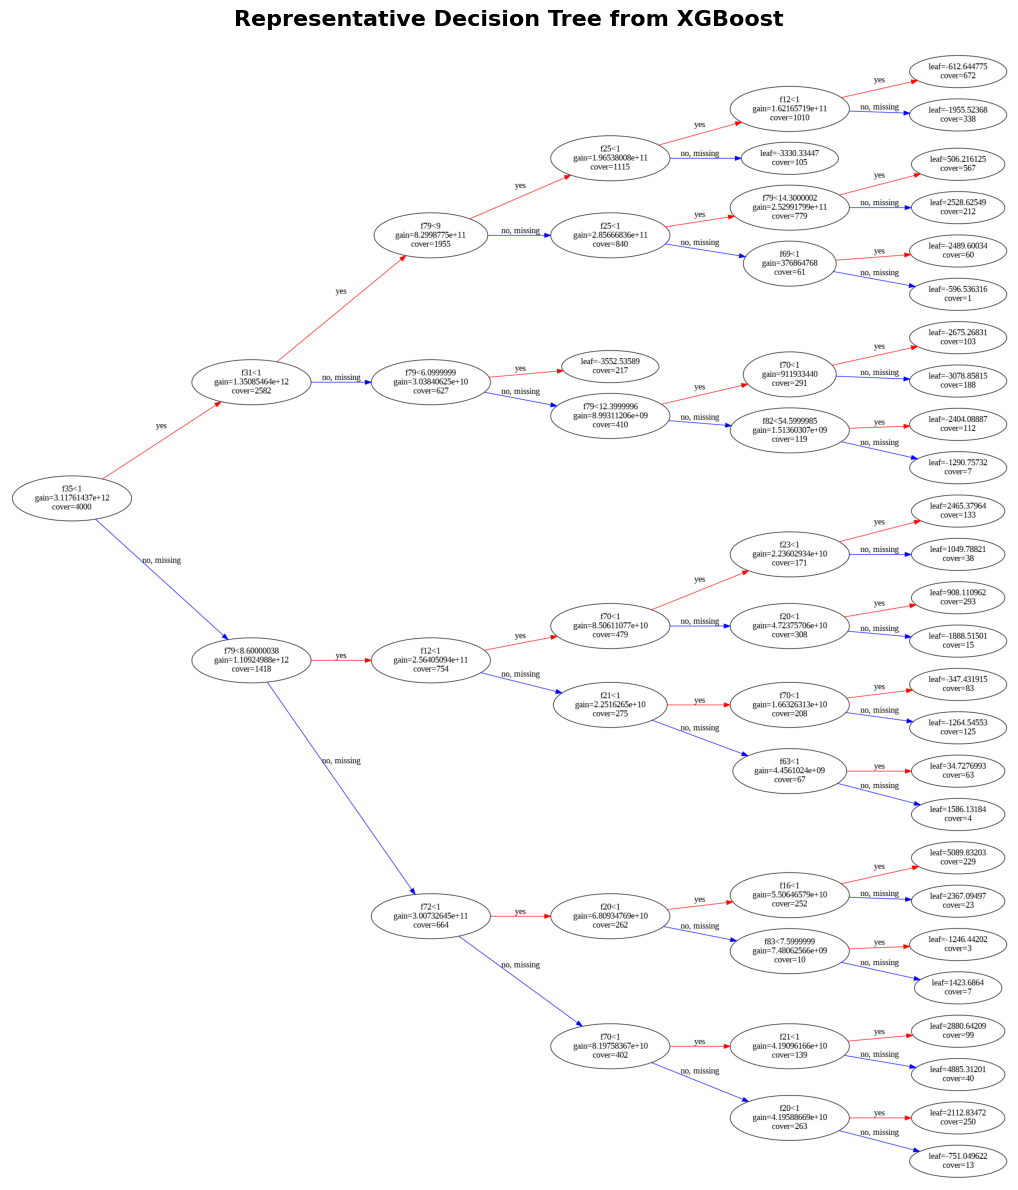

In [99]:
import xgboost as xgb
import matplotlib.pyplot as plt

# Extract trained XGBoost model
xgb_model = fitted_pipelines['XGBoost'].named_steps['model']

# Create figure and axes explicitly
fig, ax = plt.subplots(figsize=(24, 12))

# Plot the first tree
xgb.plot_tree(
    xgb_model,
    tree_idx=0,
    rankdir='LR',
    ax=ax,
    with_stats=True
)

ax.set_title(
    "Representative Decision Tree from XGBoost",
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

### 7.3.3 LightGBM — Representative Tree

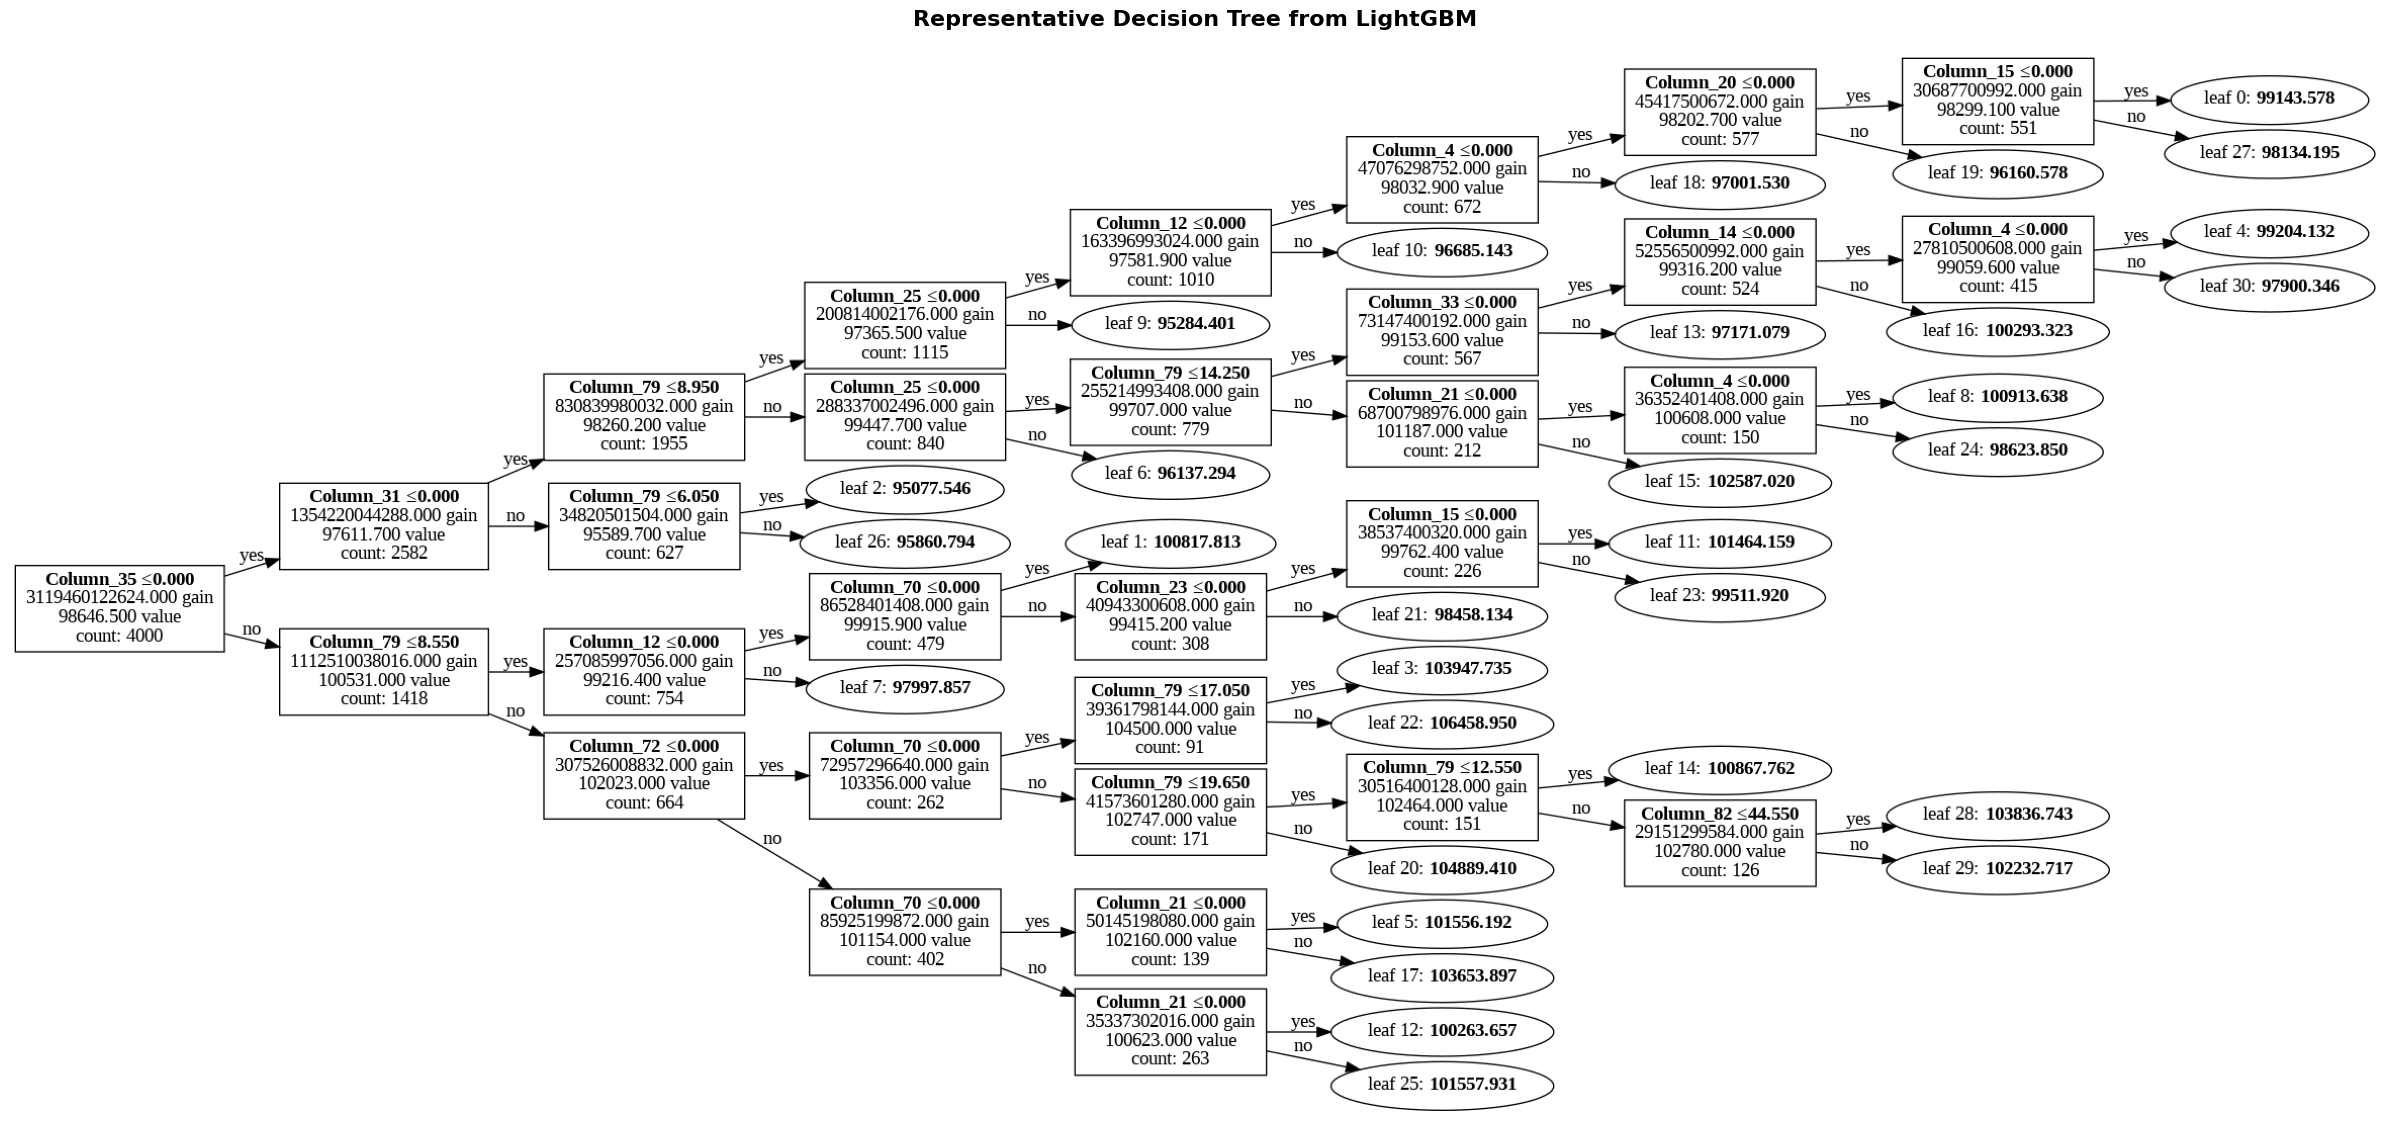

In [100]:
import lightgbm as lgb
import matplotlib.pyplot as plt

# Extract trained LightGBM model
lgb_model = fitted_pipelines['LightGBM'].named_steps['model']

# Create figure and axes explicitly
fig, ax = plt.subplots(figsize=(24, 12))

# Plot the first tree
lgb.plot_tree(
    lgb_model,
    tree_index=0,
    ax=ax,
    figsize=(24, 12),
    show_info=[
        'split_gain',
        'internal_value',
        'internal_count'
    ]
)

ax.set_title(
    "Representative Decision Tree from LightGBM",
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()

## 7.4 Model Performance comparision

In [101]:
results_df = (
    pd.DataFrame(results)
    .sort_values('R2 Score', ascending=False)
    .reset_index(drop=True)
)

results_df

,Model,R2 Score,MAE,RMSE
0,CatBoost,0.847206,15209.877381,21561.399722
1,LightGBM,0.839814,15348.075091,22076.769525
2,XGBoost,0.837418,15585.069336,22241.297084
3,Linear Regression,0.806208,18113.782881,24282.391654
4,Random Forest,0.768754,18685.542383,26525.319240
5,Extra Trees,0.763990,18776.870737,26797.158773


In [102]:
results_display = results_df.copy()

results_display['R2 Score'] = results_display['R2 Score'].round(4)
results_display['MAE'] = results_display['MAE'].round(2)
results_display['RMSE'] = results_display['RMSE'].round(2)

results_display

,Model,R2 Score,MAE,RMSE
0,CatBoost,0.8472,15209.88,21561.40
1,LightGBM,0.8398,15348.08,22076.77
2,XGBoost,0.8374,15585.07,22241.30
3,Linear Regression,0.8062,18113.78,24282.39
4,Random Forest,0.7688,18685.54,26525.32
5,Extra Trees,0.7640,18776.87,26797.16


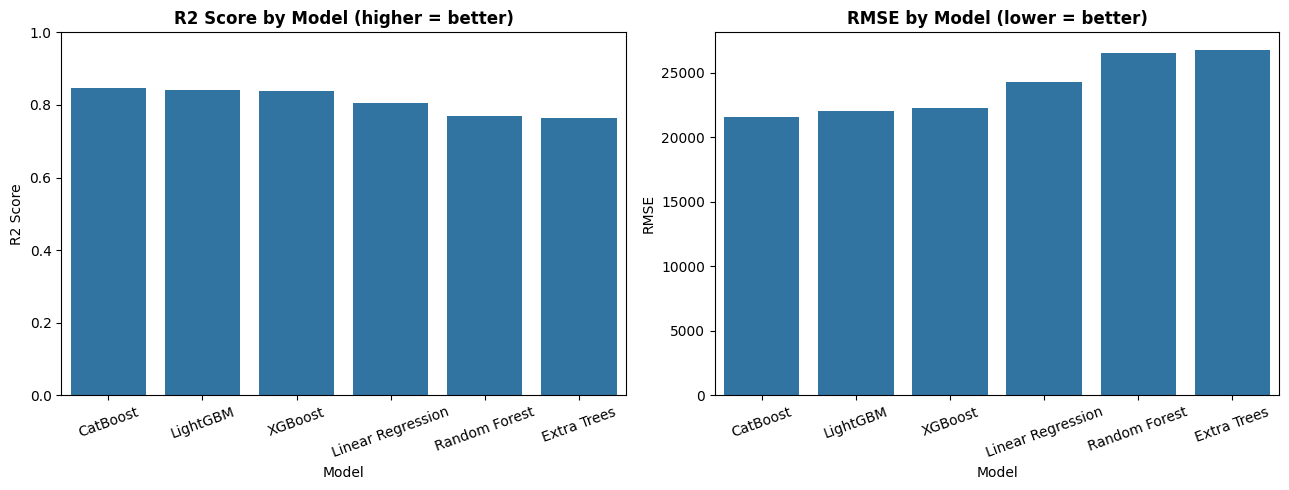

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

sns.barplot(data=results_df, x='Model', y='R2 Score', ax=axes[0])
axes[0].set_title("R2 Score by Model (higher = better)",fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='Model', y='RMSE', ax=axes[1])
axes[1].set_title("RMSE by Model (lower = better)",fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### 7.5 Feature Importance (Best Model)
Which features drive the model's salary predictions the most?

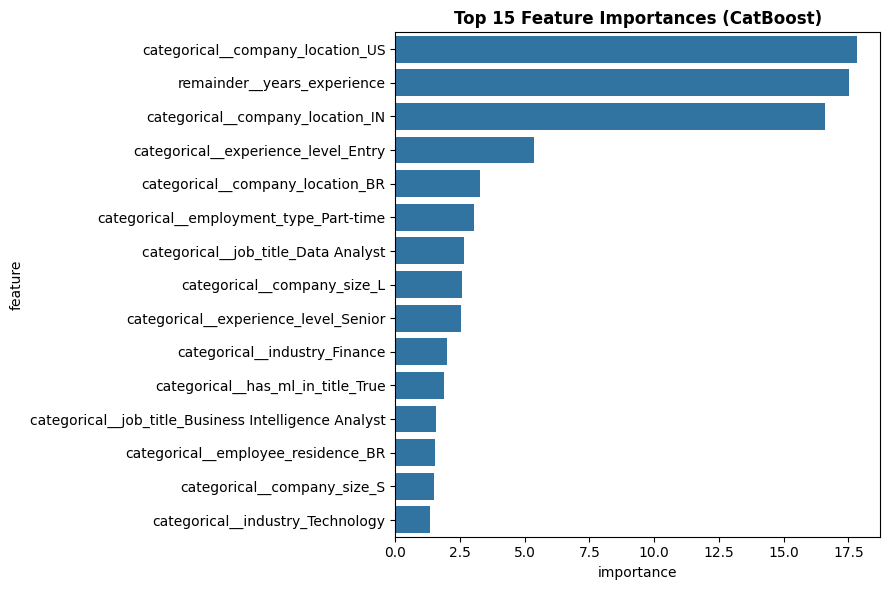

In [104]:
best_model_name = results_df.iloc[0]['Model']
best_pipe = fitted_pipelines[best_model_name]

feature_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()
importances = best_pipe.named_steps['model'].feature_importances_

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(9,6))
sns.barplot(data=fi_df, x='importance', y='feature')
plt.title(f"Top 15 Feature Importances ({best_model_name})",fontweight='bold')
plt.tight_layout()
plt.show()

In [105]:

import pandas as pd
import matplotlib.pyplot as plt


best_pipeline = fitted_pipelines['LightGBM']

lgb_model = best_pipeline.named_steps['model']

preprocessor_fitted = best_pipeline.named_steps['preprocessor']

transformed_feature_names = (
    preprocessor_fitted.get_feature_names_out()
)


importance_values = lgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Importance': importance_values
})

feature_importance_df = (
    feature_importance_df
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

feature_importance_df.head(15)

,Feature,Importance
0,remainder__years_experience,1059
1,remainder__weekly_hours,996
2,remainder__bonus_pct,853
3,remainder__equity_offered_pct,793
4,remainder__upskilling_hours_per_month,779
5,remainder__ai_tools_hours_per_week,767
6,remainder__fears_ai_automation_score,731
7,remainder__job_satisfaction_score,711
8,remainder__interviews_to_offer,361
9,remainder__team_size,344


## 7.5.1 Aggregate Importance by Original Feature

In [106]:
# Get fitted preprocessing components
preprocessor_fitted = (
    fitted_pipelines['LightGBM']
    .named_steps['preprocessor']
)

encoder = preprocessor_fitted.named_transformers_['categorical']

# Get all transformed feature names
encoded_feature_names = encoder.get_feature_names_out(cat_cols)

# Get LightGBM feature importances
lgb_model = fitted_pipelines['LightGBM'].named_steps['model']

importance_values = lgb_model.feature_importances_

# Get all transformed feature names from the full preprocessor
transformed_feature_names = (
    preprocessor_fitted.get_feature_names_out()
)

# Create mapping
feature_mapping = []

# Map one-hot encoded categorical features
for encoded_name in encoded_feature_names:

    original_feature = None

    for cat in cat_cols:
        if encoded_name.startswith(cat + "_"):
            original_feature = cat
            break

    feature_mapping.append({
        'Transformed Feature': 'categorical__' + encoded_name,
        'Original Feature': original_feature
    })

# Map numerical features
for feature in num_cols:
    feature_mapping.append({
        'Transformed Feature': 'remainder__' + feature,
        'Original Feature': feature
    })

mapping_df = pd.DataFrame(feature_mapping)

# Create importance dataframe
importance_df = pd.DataFrame({
    'Transformed Feature': transformed_feature_names,
    'Importance': importance_values
})

# Merge
importance_mapped = importance_df.merge(
    mapping_df,
    on='Transformed Feature',
    how='left'
)

# Aggregate by original feature
aggregated_importance = (
    importance_mapped
    .groupby('Original Feature', as_index=False)['Importance']
    .sum()
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

aggregated_importance.head(15)

,Original Feature,Importance
0,years_experience,1059
1,weekly_hours,996
2,company_location,864
3,bonus_pct,853
4,equity_offered_pct,793
5,upskilling_hours_per_month,779
6,ai_tools_hours_per_week,767
7,fears_ai_automation_score,731
8,job_satisfaction_score,711
9,job_title,622


### 7.5.2 Plot Top 15 Original Features

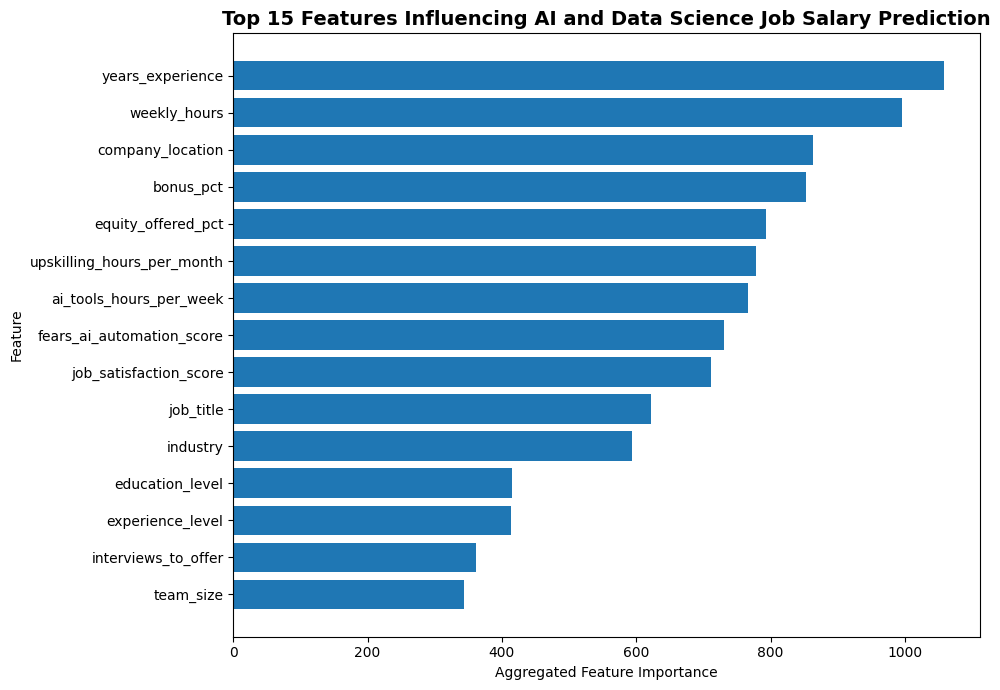

In [107]:
# Top 15 original features
top_features = aggregated_importance.head(15).sort_values(
    'Importance',
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features['Original Feature'],
    top_features['Importance']
)

plt.xlabel('Aggregated Feature Importance')
plt.ylabel('Feature')
plt.title(
    'Top 15 Features Influencing AI and Data Science Job Salary Prediction',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [108]:
top_importance_table = aggregated_importance.head(15).copy()

top_importance_table['Importance (%)'] = (
    top_importance_table['Importance']
    / aggregated_importance['Importance'].sum()
    * 100
).round(2)

top_importance_table = top_importance_table[
    ['Original Feature', 'Importance', 'Importance (%)']
]

top_importance_table

,Original Feature,Importance,Importance (%)
0,years_experience,1059,8.82
1,weekly_hours,996,8.30
2,company_location,864,7.20
3,bonus_pct,853,7.11
4,equity_offered_pct,793,6.61
5,upskilling_hours_per_month,779,6.49
6,ai_tools_hours_per_week,767,6.39
7,fears_ai_automation_score,731,6.09
8,job_satisfaction_score,711,5.92
9,job_title,622,5.18


# 8. Hyperparameter Tuning


Hyperparameter tuning was performed to optimize the performance of the two best baseline ensemble models, XGBoost and LightGBM. RandomizedSearchCV with 3-fold cross-validation was used to search for promising hyperparameter combinations using only the training data. The test set was kept completely unseen during the tuning process.


The hyperparameter tuning process follows the workflow below:

```text
Training Data
      │
      ├── 3-Fold Cross-Validation
      │
      ├── Hyperparameter Search
      │
      └── Best Parameters
                │
                ▼
          Tuned Model
                │
                ▼
          Final Test Set

In [109]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

### 8.3 Tune Light BGM

In [110]:
# Extract the preprocessing pipeline
preprocessor_for_tuning = preprocessor

# LightGBM pipeline
lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_for_tuning),
    ('model', LGBMRegressor(
        random_state=42,
        verbose=-1,
        n_jobs=-1
    ))
])

In [111]:
lgbm_param_dist = {
    'model__n_estimators': randint(200, 800),
    'model__learning_rate': uniform(0.01, 0.09),
    'model__max_depth': randint(3, 10),
    'model__num_leaves': randint(15, 80),
    'model__min_child_samples': randint(10, 50),
    'model__subsample': uniform(0.7, 0.3),
    'model__colsample_bytree': uniform(0.7, 0.3)
}

### 8.4 Run LightGBM Randomized Search

In [112]:
lgbm_search = RandomizedSearchCV(
    estimator=lgbm_pipeline,
    param_distributions=lgbm_param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning:


The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).




RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('categorical',
                                                                               OneHotEncoder(handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               ['job_title',
                                                                                'experience_level',
                                                                                'employment_type',
                                                                                'company_size',
                                                                                'company_location',
                                                                                'employee_residence',
                                                                                'industry',
                                                                                'education_level',
                                                                                'primary_language',
                                                                                '...
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f6d4ec9a150>,
                                        'model__num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f6d4efd1a90>,
                                        'model__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f6d4efd1c70>},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

### 8.5 Best LightGBM Parameters

In [113]:
print("Best LightGBM Parameters:")
print(lgbm_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-lgbm_search.best_score_)

Best LightGBM Parameters:
{'model__colsample_bytree': np.float64(0.7016566351370807), 'model__learning_rate': np.float64(0.08339152856093507), 'model__max_depth': 3, 'model__min_child_samples': 17, 'model__n_estimators': 618, 'model__num_leaves': 47, 'model__subsample': np.float64(0.8817879924343034)}

Best Cross-Validation RMSE:
21752.113912953053


### 8.6 Tune XG Boost

In [114]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror'
    ))
])

In [115]:
xgb_param_dist = {
    'model__n_estimators': randint(200, 800),
    'model__learning_rate': uniform(0.01, 0.09),
    'model__max_depth': randint(3, 10),
    'model__min_child_weight': randint(1, 10),
    'model__subsample': uniform(0.7, 0.3),
    'model__colsample_bytree': uniform(0.7, 0.3),
    'model__gamma': uniform(0, 0.5)
}

In [116]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning:


The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).




RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('categorical',
                                                                               OneHotEncoder(handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               ['job_title',
                                                                                'experience_level',
                                                                                'employment_type',
                                                                                'company_size',
                                                                                'company_location',
                                                                                'employee_residence',
                                                                                'industry',
                                                                                'education_level',
                                                                                'primary_language',
                                                                                '...
                                        'model__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f6d302c2090>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f6d4f5dd9b0>,
                                        'model__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f6d54f9fba0>},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [117]:
print("Best XGBoost Parameters:")
print(xgb_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-xgb_search.best_score_)

Best XGBoost Parameters:
{'model__colsample_bytree': np.float64(0.8400288679743939), 'model__gamma': np.float64(0.4299702033681603), 'model__learning_rate': np.float64(0.07122767847290017), 'model__max_depth': 3, 'model__min_child_weight': 7, 'model__n_estimators': 473, 'model__subsample': np.float64(0.9846656611759999)}

Best Cross-Validation RMSE:
21776.446614583332


### 8.10 Tune Extra Trees

In [118]:
et_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ExtraTreesRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

In [119]:
et_param_dist = {
    'model__n_estimators': randint(200, 800),
    'model__max_features': ['sqrt', 'log2', 0.5, 0.7, 0.9],
    'model__min_samples_split': randint(2, 20),
    'model__min_samples_leaf': randint(1, 20),
    'model__bootstrap': [True, False]
}

### 8.11 Run Extra Trees Randomized Search

In [120]:
et_search = RandomizedSearchCV(
    estimator=et_pipeline,
    param_distributions=et_param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

et_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning:


The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).




RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('categorical',
                                                                               OneHotEncoder(handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               ['job_title',
                                                                                'experience_level',
                                                                                'employment_type',
                                                                                'company_size',
                                                                                'company_location',
                                                                                'employee_residence',
                                                                                'industry',
                                                                                'education_level',
                                                                                'primary_language',
                                                                                '...
                                        'model__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f6d4f353070>,
                                        'model__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f6d4f352d00>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f6d5cbdb110>},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

### 8.12 Best Extra Trees Parameters

In [121]:
print("Best Extra Trees Parameters:")
print(et_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-et_search.best_score_)

Best Extra Trees Parameters:
{'model__bootstrap': True, 'model__max_features': 0.9, 'model__min_samples_leaf': 1, 'model__min_samples_split': 8, 'model__n_estimators': 720}

Best Cross-Validation RMSE:
24090.226976184844


### 8.7 Tune CatBoost

In [122]:
catboost_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', CatBoostRegressor(
        random_seed=42,
        verbose=0,
        allow_writing_files=False
    ))
])

In [123]:
catboost_param_dist = {
    'model__iterations': randint(200, 800),
    'model__learning_rate': uniform(0.01, 0.09),
    'model__depth': randint(3, 10),
    'model__l2_leaf_reg': uniform(1, 10),
    'model__subsample': uniform(0.7, 0.3)
}

### 8.8 Run CatBoost Randomized Search

In [124]:
catboost_search = RandomizedSearchCV(
    estimator=catboost_pipeline,
    param_distributions=catboost_param_dist,
    n_iter=20,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

catboost_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning:


The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).




RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('categorical',
                                                                               OneHotEncoder(handle_unknown='ignore',
                                                                                             sparse_output=False),
                                                                               ['job_title',
                                                                                'experience_level',
                                                                                'employment_type',
                                                                                'company_size',
                                                                                'company_location',
                                                                                'employee_residence',
                                                                                'industry',
                                                                                'education_level',
                                                                                'primary_language',
                                                                                '...
                                        'model__l2_leaf_reg': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f6d4f351b20>,
                                        'model__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f6d4f351e90>,
                                        'model__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f6d4f438a50>},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

### 8.9 Best CatBoost Parameters

In [125]:
print("Best CatBoost Parameters:")
print(catboost_search.best_params_)

print("\nBest Cross-Validation RMSE:")
print(-catboost_search.best_score_)

Best CatBoost Parameters:
{'model__depth': 6, 'model__iterations': 579, 'model__l2_leaf_reg': np.float64(3.7599918202254337), 'model__learning_rate': np.float64(0.036664615513367416), 'model__subsample': np.float64(0.7495800817189007)}

Best Cross-Validation RMSE:
21175.14276460076


### 9.1 Evaluate Tuned Models

In [126]:
tuned_models = {
    'Tuned LightGBM': lgbm_search.best_estimator_,
    'Tuned XGBoost': xgb_search.best_estimator_,
    'Tuned CatBoost': catboost_search.best_estimator_,
    'Tuned Extra Trees': et_search.best_estimator_
}

tuned_results = [] # Re-initialize tuned_results to avoid appending to previous runs
tuned_pipelines = {} # Re-initialize tuned_pipelines


for name, pipe in tuned_models.items():

    # Predict on untouched test set
    preds = pipe.predict(X_test)

    # Calculate evaluation metrics
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    tuned_results.append({
        'Model': name,
        'R2 Score': r2,
        'MAE': mae,
        'RMSE': rmse
    })

    tuned_pipelines[name] = pipe

tuned_results_df = (
    pd.DataFrame(tuned_results)
    .sort_values('R2 Score', ascending=False)
    .reset_index(drop=True)
)

display(tuned_results_df)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



,Model,R2 Score,MAE,RMSE
0,Tuned CatBoost,0.847467,15083.041022,21542.936886
1,Tuned LightGBM,0.844293,15432.346259,21765.916172
2,Tuned XGBoost,0.841614,15525.496094,21952.406702
3,Tuned Extra Trees,0.805912,17126.694525,24300.892414


### Comparison: Tuned Extra Trees vs. Tuned CatBoost

In [127]:
extra_trees_vs_catboost_comparison = tuned_results_df[
    tuned_results_df['Model'].isin(['Tuned Extra Trees', 'Tuned CatBoost'])
].sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
display(extra_trees_vs_catboost_comparison)

,Model,R2 Score,MAE,RMSE
0,Tuned CatBoost,0.847467,15083.041022,21542.936886
1,Tuned Extra Trees,0.805912,17126.694525,24300.892414


/tmp/ipykernel_774/3564187113.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




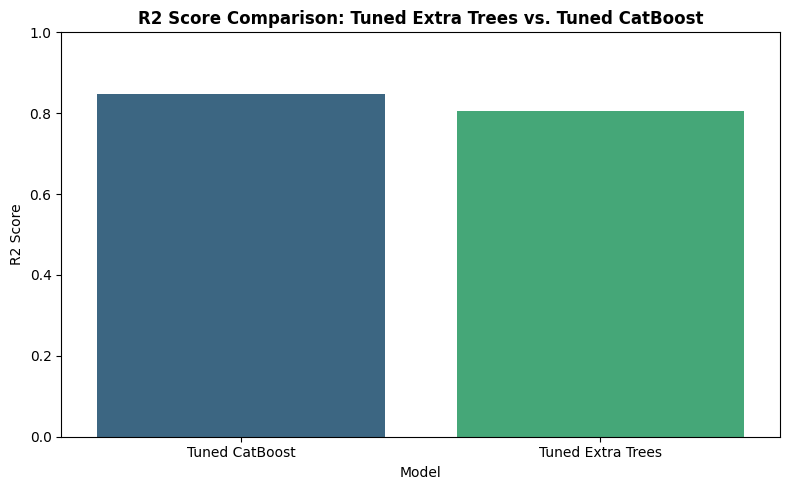

In [128]:
plt.figure(figsize=(8, 5))
sns.barplot(data=extra_trees_vs_catboost_comparison, x='Model', y='R2 Score', palette='viridis')
plt.title('R2 Score Comparison: Tuned Extra Trees vs. Tuned CatBoost', fontweight='bold')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.ylim(0, 1) # R2 score is between 0 and 1
plt.tight_layout()
plt.show()

/tmp/ipykernel_774/176995059.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




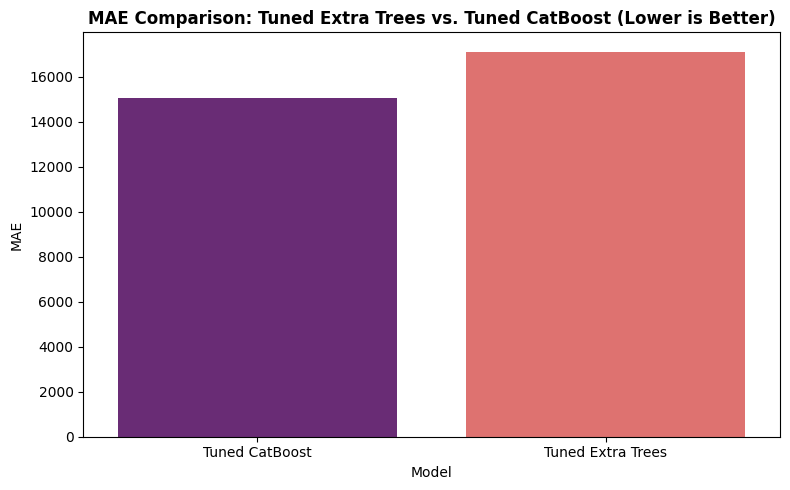

In [129]:
plt.figure(figsize=(8, 5))
sns.barplot(data=extra_trees_vs_catboost_comparison, x='Model', y='MAE', palette='magma')
plt.title('MAE Comparison: Tuned Extra Trees vs. Tuned CatBoost (Lower is Better)', fontweight='bold')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

/tmp/ipykernel_774/613547088.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




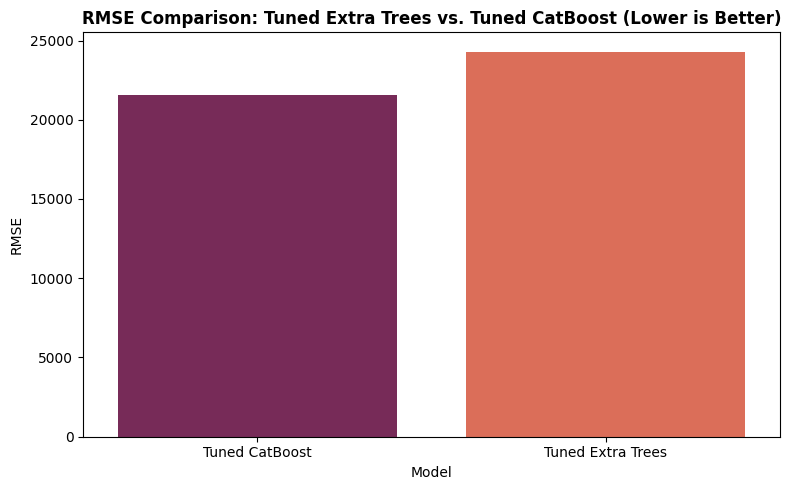

In [130]:
plt.figure(figsize=(8, 5))
sns.barplot(data=extra_trees_vs_catboost_comparison, x='Model', y='RMSE', palette='rocket')
plt.title('RMSE Comparison: Tuned Extra Trees vs. Tuned CatBoost (Lower is Better)', fontweight='bold')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.tight_layout()
plt.show()

In [131]:
tuned_models = {
    'Tuned LightGBM': lgbm_search.best_estimator_,
    'Tuned XGBoost': xgb_search.best_estimator_,
    'Tuned CatBoost': catboost_search.best_estimator_,
    'Tuned Extra Trees': et_search.best_estimator_
}

tuned_results = [] # Re-initialize tuned_results to avoid appending to previous runs
tuned_pipelines = {} # Re-initialize tuned_pipelines

for name, pipe in tuned_models.items():

    # Predict on untouched test set
    preds = pipe.predict(X_test)

    # Calculate evaluation metrics
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5

    tuned_results.append({
        'Model': name,
        'R2 Score': r2,
        'MAE': mae,
        'RMSE': rmse
    })

    tuned_pipelines[name] = pipe

tuned_results_df = (
    pd.DataFrame(tuned_results)
    .sort_values('R2 Score', ascending=False)
    .reset_index(drop=True)
)

display(tuned_results_df)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LGBMRegressor was fitted with feature names



,Model,R2 Score,MAE,RMSE
0,Tuned CatBoost,0.847467,15083.041022,21542.936886
1,Tuned LightGBM,0.844293,15432.346259,21765.916172
2,Tuned XGBoost,0.841614,15525.496094,21952.406702
3,Tuned Extra Trees,0.805912,17126.694525,24300.892414


## 9.2 Baseline vs Tuned Model Comparison

In [132]:
baseline_comparison = results_df[
    ['Model', 'R2 Score', 'MAE', 'RMSE']
].copy()

tuned_comparison = tuned_results_df.loc[
    tuned_results_df['Model'].isin(['Tuned LightGBM', 'Tuned XGBoost', 'Tuned CatBoost'])
][['Model', 'R2 Score', 'MAE', 'RMSE']].copy()

comparison_df = pd.concat(
    [baseline_comparison, tuned_comparison],
    ignore_index=True
)

comparison_df

,Model,R2 Score,MAE,RMSE
0,CatBoost,0.847206,15209.877381,21561.399722
1,LightGBM,0.839814,15348.075091,22076.769525
2,XGBoost,0.837418,15585.069336,22241.297084
3,Linear Regression,0.806208,18113.782881,24282.391654
4,Random Forest,0.768754,18685.542383,26525.319240
5,Extra Trees,0.763990,18776.870737,26797.158773
6,Tuned CatBoost,0.847467,15083.041022,21542.936886
7,Tuned LightGBM,0.844293,15432.346259,21765.916172
8,Tuned XGBoost,0.841614,15525.496094,21952.406702


In [133]:
baseline_comparison = results_df[
    ['Model', 'R2 Score', 'MAE', 'RMSE']
].copy()

tuned_comparison = tuned_results_df.loc[
    tuned_results_df['Model'].isin([
        'Tuned LightGBM',
        'Tuned XGBoost',
        'Tuned CatBoost',
        'Tuned Extra Trees' # Include Extra Trees
    ])
][['Model', 'R2 Score', 'MAE', 'RMSE']].copy()

comparison_df = pd.concat(
    [baseline_comparison, tuned_comparison],
    ignore_index=True
)

comparison_df

,Model,R2 Score,MAE,RMSE
0,CatBoost,0.847206,15209.877381,21561.399722
1,LightGBM,0.839814,15348.075091,22076.769525
2,XGBoost,0.837418,15585.069336,22241.297084
3,Linear Regression,0.806208,18113.782881,24282.391654
4,Random Forest,0.768754,18685.542383,26525.319240
5,Extra Trees,0.763990,18776.870737,26797.158773
6,Tuned CatBoost,0.847467,15083.041022,21542.936886
7,Tuned LightGBM,0.844293,15432.346259,21765.916172
8,Tuned XGBoost,0.841614,15525.496094,21952.406702
9,Tuned Extra Trees,0.805912,17126.694525,24300.892414


##  9.3 Improvement Calculation

In [134]:
baseline_lgbm = results_df.loc[
    results_df['Model'] == 'LightGBM'
].iloc[0]

baseline_xgb = results_df.loc[
    results_df['Model'] == 'XGBoost'
].iloc[0]

tuned_lgbm = tuned_results_df.loc[
    tuned_results_df['Model'] == 'Tuned LightGBM'
].iloc[0]

tuned_xgb = tuned_results_df.loc[
    tuned_results_df['Model'] == 'Tuned XGBoost'
].iloc[0]


improvement_df = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost'],

    'R2 Improvement': [
        tuned_lgbm['R2 Score'] - baseline_lgbm['R2 Score'],
        tuned_xgb['R2 Score'] - baseline_xgb['R2 Score']
    ],

    'MAE Improvement': [
        baseline_lgbm['MAE'] - tuned_lgbm['MAE'],
        baseline_xgb['MAE'] - tuned_xgb['MAE']
    ],

    'RMSE Improvement': [
        baseline_lgbm['RMSE'] - tuned_lgbm['RMSE'],
        baseline_xgb['RMSE'] - tuned_xgb['RMSE']
    ]
})

improvement_df

,Model,R2 Improvement,MAE Improvement,RMSE Improvement
0,LightGBM,0.004479,-84.271169,310.853353
1,XGBoost,0.004196,59.573242,288.890383


In [135]:
baseline_lgbm = results_df.loc[
    results_df['Model'] == 'LightGBM'
].iloc[0]

baseline_xgb = results_df.loc[
    results_df['Model'] == 'XGBoost'
].iloc[0]

baseline_catboost = results_df.loc[
    results_df['Model'] == 'CatBoost'
].iloc[0]

tuned_lgbm = tuned_results_df.loc[
    tuned_results_df['Model'] == 'Tuned LightGBM'
].iloc[0]

tuned_xgb = tuned_results_df.loc[
    tuned_results_df['Model'] == 'Tuned XGBoost'
].iloc[0]

tuned_catboost = tuned_results_df.loc[
    tuned_results_df['Model'] == 'Tuned CatBoost'
].iloc[0]


improvement_df = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost', 'CatBoost'],

    'R2 Improvement': [
        tuned_lgbm['R2 Score'] - baseline_lgbm['R2 Score'],
        tuned_xgb['R2 Score'] - baseline_xgb['R2 Score'],
        tuned_catboost['R2 Score'] - baseline_catboost['R2 Score']
    ],

    'MAE Improvement': [
        baseline_lgbm['MAE'] - tuned_lgbm['MAE'],
        baseline_xgb['MAE'] - tuned_xgb['MAE'],
        baseline_catboost['MAE'] - tuned_catboost['MAE']
    ],

    'RMSE Improvement': [
        baseline_lgbm['RMSE'] - tuned_lgbm['RMSE'],
        baseline_xgb['RMSE'] - tuned_xgb['RMSE'],
        baseline_catboost['RMSE'] - tuned_catboost['RMSE']
    ]
})

display(improvement_df)

,Model,R2 Improvement,MAE Improvement,RMSE Improvement
0,LightGBM,0.004479,-84.271169,310.853353
1,XGBoost,0.004196,59.573242,288.890383
2,CatBoost,0.000262,126.836359,18.462836


In [136]:
baseline_lgbm = results_df.loc[
    results_df['Model'] == 'LightGBM'
].iloc[0]

baseline_xgb = results_df.loc[
    results_df['Model'] == 'XGBoost'
].iloc[0]

baseline_catboost = results_df.loc[
    results_df['Model'] == 'CatBoost'
].iloc[0]

baseline_et = results_df.loc[
    results_df['Model'] == 'Extra Trees'
].iloc[0] # Get baseline for Extra Trees

tuned_lgbm = tuned_results_df.loc[
    tuned_results_df['Model'] == 'Tuned LightGBM'
].iloc[0]

tuned_xgb = tuned_results_df.loc[
    tuned_results_df['Model'] == 'Tuned XGBoost'
].iloc[0]

tuned_catboost = tuned_results_df.loc[
    tuned_results_df['Model'] == 'Tuned CatBoost'
].iloc[0]

tuned_et = tuned_results_df.loc[
    tuned_results_df['Model'] == 'Tuned Extra Trees'
].iloc[0] # Get tuned for Extra Trees


improvement_df = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost', 'CatBoost', 'Extra Trees'], # Add Extra Trees

    'R2 Improvement': [
        tuned_lgbm['R2 Score'] - baseline_lgbm['R2 Score'],
        tuned_xgb['R2 Score'] - baseline_xgb['R2 Score'],
        tuned_catboost['R2 Score'] - baseline_catboost['R2 Score'],
        tuned_et['R2 Score'] - baseline_et['R2 Score'] # Add Extra Trees
    ],

    'MAE Improvement': [
        baseline_lgbm['MAE'] - tuned_lgbm['MAE'],
        baseline_xgb['MAE'] - tuned_xgb['MAE'],
        baseline_catboost['MAE'] - tuned_catboost['MAE'],
        baseline_et['MAE'] - tuned_et['MAE'] # Add Extra Trees
    ],

    'RMSE Improvement': [
        baseline_lgbm['RMSE'] - tuned_lgbm['RMSE'],
        baseline_xgb['RMSE'] - tuned_xgb['RMSE'],
        baseline_catboost['RMSE'] - tuned_catboost['RMSE'],
        baseline_et['RMSE'] - tuned_et['RMSE'] # Add Extra Trees
    ]
})

display(improvement_df)

,Model,R2 Improvement,MAE Improvement,RMSE Improvement
0,LightGBM,0.004479,-84.271169,310.853353
1,XGBoost,0.004196,59.573242,288.890383
2,CatBoost,0.000262,126.836359,18.462836
3,Extra Trees,0.041923,1650.176212,2496.266360


## 9.4 Visualize Final Model Comparison

/tmp/ipykernel_774/4256833416.py:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_774/4256833416.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_774/4256833416.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




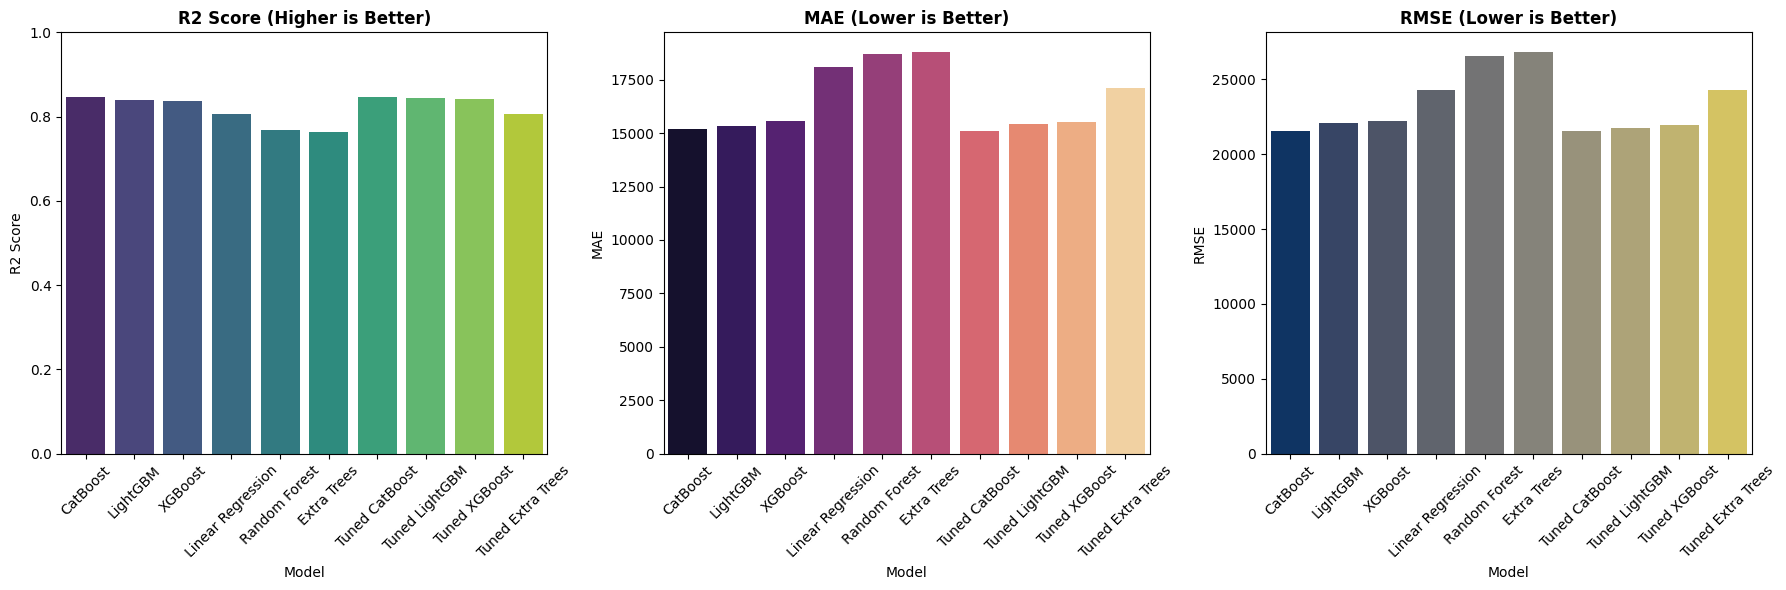

In [137]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# R2 Score Plot
sns.barplot(data=comparison_df, x='Model', y='R2 Score', ax=axes[0], palette='viridis')
axes[0].set_title('R2 Score (Higher is Better)', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

# MAE Plot
sns.barplot(data=comparison_df, x='Model', y='MAE', ax=axes[1], palette='magma')
axes[1].set_title('MAE (Lower is Better)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

# RMSE Plot
sns.barplot(data=comparison_df, x='Model', y='RMSE', ax=axes[2], palette='cividis')
axes[2].set_title('RMSE (Lower is Better)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 9.5 R2 Score Comparison of All Models

/tmp/ipykernel_774/3033788643.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




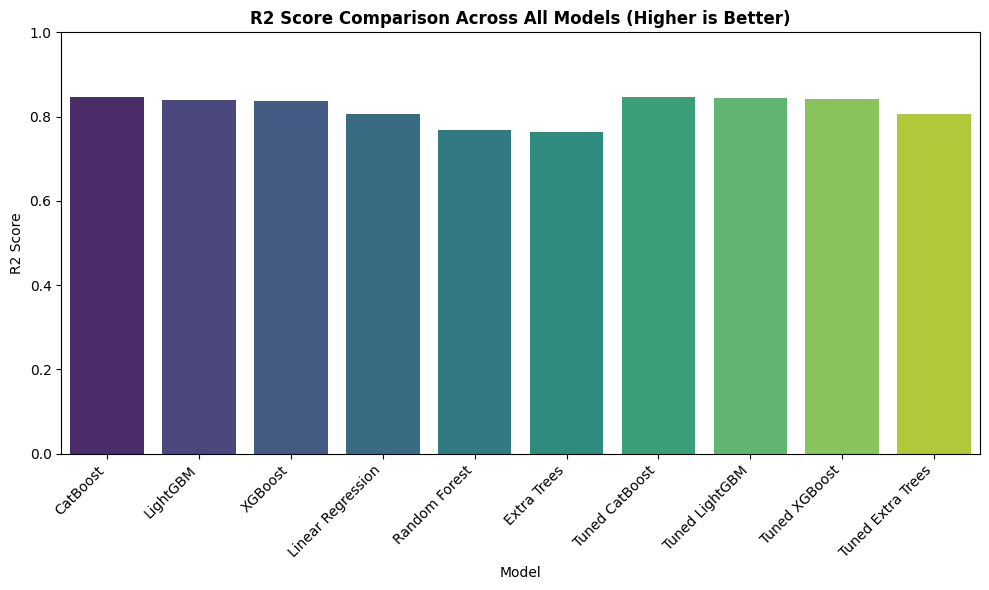

In [138]:
plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x='Model', y='R2 Score', palette='viridis')
plt.title('R2 Score Comparison Across All Models (Higher is Better)', fontweight='bold')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.ylim(0, 1) # R2 score is between 0 and 1
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9.6 Feature Importance for Tuned CatBoost Model

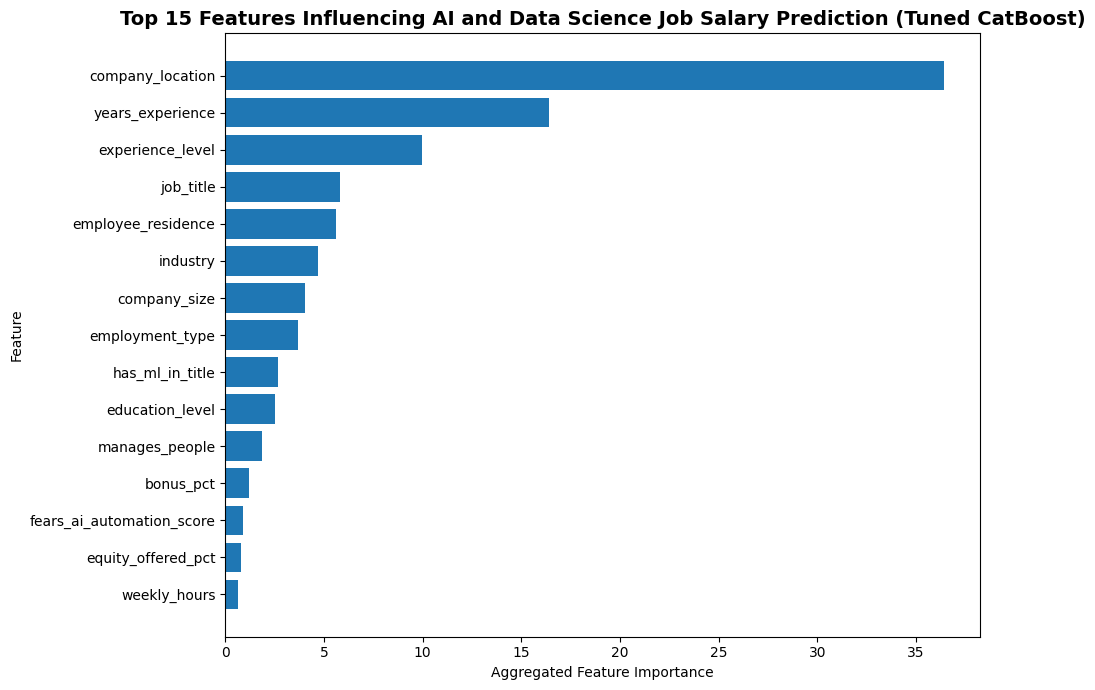

,Original Feature,Importance
0,company_location,36.412040
1,years_experience,16.415939
2,experience_level,9.950342
3,job_title,5.824038
4,employee_residence,5.590487
5,industry,4.712880
6,company_size,4.032143
7,employment_type,3.690289
8,has_ml_in_title,2.651570
9,education_level,2.503188


In [139]:
# Get the best tuned CatBoost pipeline
best_tuned_catboost_pipeline = catboost_search.best_estimator_

# Extract the CatBoost model and preprocessor
catboost_model = best_tuned_catboost_pipeline.named_steps['model']
preprocessor_fitted_catboost = best_tuned_catboost_pipeline.named_steps['preprocessor']

# Get all transformed feature names
transformed_feature_names_catboost = (
    preprocessor_fitted_catboost.get_feature_names_out()
)

# Get CatBoost feature importances
importance_values_catboost = catboost_model.get_feature_importance()

# Create mapping (re-using cat_cols and num_cols from earlier preprocessing)
feature_mapping_catboost = []

# Map one-hot encoded categorical features
encoder_catboost = preprocessor_fitted_catboost.named_transformers_['categorical']
encoded_feature_names_catboost = encoder_catboost.get_feature_names_out(cat_cols)

for encoded_name in encoded_feature_names_catboost:
    original_feature = None
    for cat in cat_cols:
        if encoded_name.startswith(cat + "_"):
            original_feature = cat
            break
    feature_mapping_catboost.append({
        'Transformed Feature': 'categorical__' + encoded_name,
        'Original Feature': original_feature
    })

# Map numerical features
for feature in num_cols:
    feature_mapping_catboost.append({
        'Transformed Feature': 'remainder__' + feature,
        'Original Feature': feature
    })

mapping_df_catboost = pd.DataFrame(feature_mapping_catboost)

# Create importance dataframe
importance_df_catboost = pd.DataFrame({
    'Transformed Feature': transformed_feature_names_catboost,
    'Importance': importance_values_catboost
})

# Merge
importance_mapped_catboost = importance_df_catboost.merge(
    mapping_df_catboost,
    on='Transformed Feature',
    how='left'
)

# Aggregate by original feature
aggregated_importance_catboost = (
    importance_mapped_catboost
    .groupby('Original Feature', as_index=False)['Importance']
    .sum()
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)

# Top 15 original features
top_features_catboost = aggregated_importance_catboost.head(15).sort_values(
    'Importance',
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features_catboost['Original Feature'],
    top_features_catboost['Importance']
)

plt.xlabel('Aggregated Feature Importance')
plt.ylabel('Feature')
plt.title(
    'Top 15 Features Influencing AI and Data Science Job Salary Prediction (Tuned CatBoost)',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

display(aggregated_importance_catboost.head(15))

## 9.7 Residual Analysis for Tuned CatBoost Model

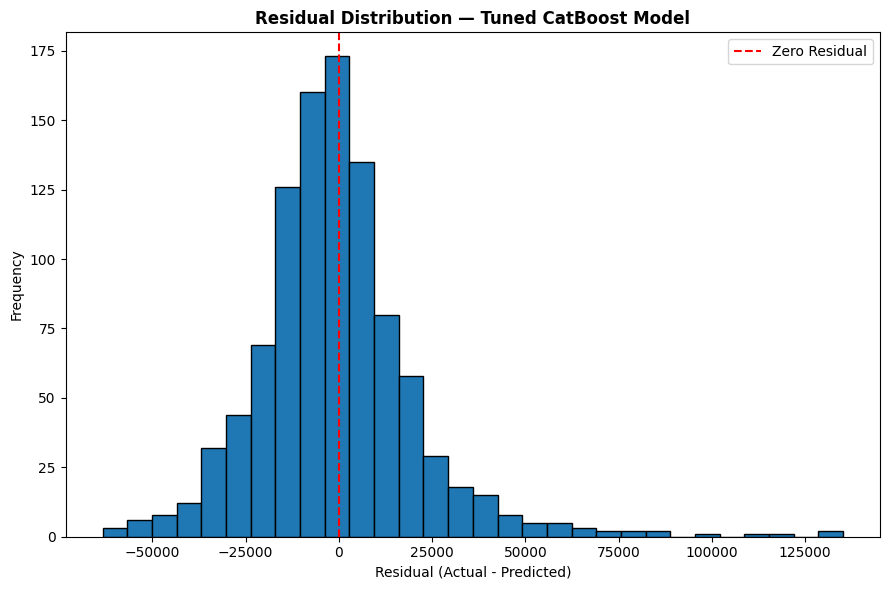

In [140]:
# Select the tuned CatBoost model
tuned_catboost_pipeline = tuned_pipelines['Tuned CatBoost']

# Make predictions on the test set
catboost_predictions = tuned_catboost_pipeline.predict(X_test)

# Calculate residuals
catboost_residuals = y_test - catboost_predictions

# Create a DataFrame for residuals for easier plotting
catboost_residuals_df = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': catboost_predictions,
    'Residual': catboost_residuals
})

# Plot Residual Distribution
plt.figure(figsize=(9, 6))

plt.hist(
    catboost_residuals_df['Residual'],
    bins=30,
    edgecolor='black'
)

plt.axvline(
    0,
    linestyle='--',
    color='red',
    label='Zero Residual'
)

plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title(
    'Residual Distribution — Tuned CatBoost Model',
    fontweight='bold'
)

plt.legend()
plt.tight_layout()
plt.show()

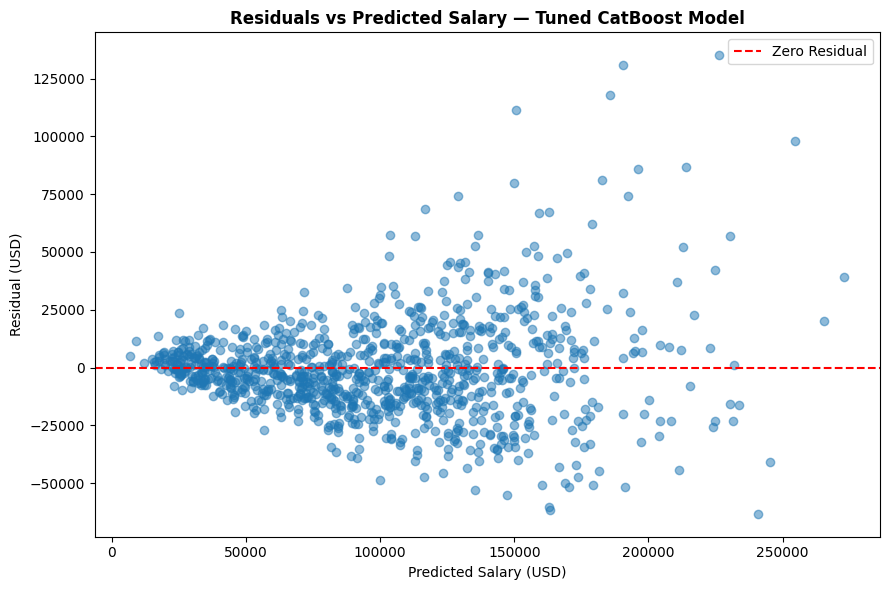

In [141]:
plt.figure(figsize=(9, 6))

plt.scatter(
    catboost_residuals_df['Predicted Salary'],
    catboost_residuals_df['Residual'],
    alpha=0.5
)

plt.axhline(
    0,
    linestyle='--',
    color='red',
    label='Zero Residual'
)

plt.xlabel('Predicted Salary (USD)')
plt.ylabel('Residual (USD)')
plt.title(
    'Residuals vs Predicted Salary — Tuned CatBoost Model',
    fontweight='bold'
)

plt.legend()
plt.tight_layout()
plt.show()

In [142]:
display(comparison_df.sort_values(by='R2 Score', ascending=False).reset_index(drop=True))

,Model,R2 Score,MAE,RMSE
0,Tuned CatBoost,0.847467,15083.041022,21542.936886
1,CatBoost,0.847206,15209.877381,21561.399722
2,Tuned LightGBM,0.844293,15432.346259,21765.916172
3,Tuned XGBoost,0.841614,15525.496094,21952.406702
4,LightGBM,0.839814,15348.075091,22076.769525
5,XGBoost,0.837418,15585.069336,22241.297084
6,Linear Regression,0.806208,18113.782881,24282.391654
7,Tuned Extra Trees,0.805912,17126.694525,24300.892414
8,Random Forest,0.768754,18685.542383,26525.319240
9,Extra Trees,0.763990,18776.870737,26797.158773


# 10. Prediction & Residual Analysis

### 10.1 Select Best Tuned Model

In [143]:
best_tuned_name = tuned_results_df.iloc[0]['Model']
best_tuned_pipeline = tuned_pipelines[best_tuned_name]

print("Best Tuned Model:", best_tuned_name)

Best Tuned Model: Tuned CatBoost


In [144]:
final_predictions = best_tuned_pipeline.predict(X_test)

prediction_df = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': final_predictions
})

prediction_df.head(10)

,Actual Salary,Predicted Salary
0,36976,36231.506830
1,65737,83211.941063
2,31555,45333.650097
3,59230,50287.192353
4,34279,40683.019574
5,135891,118419.321056
6,111590,101306.489143
7,129256,150096.127577
8,69595,70549.001676
9,174989,129672.486939


### 10.1.1 Actual vs Predicted Salary

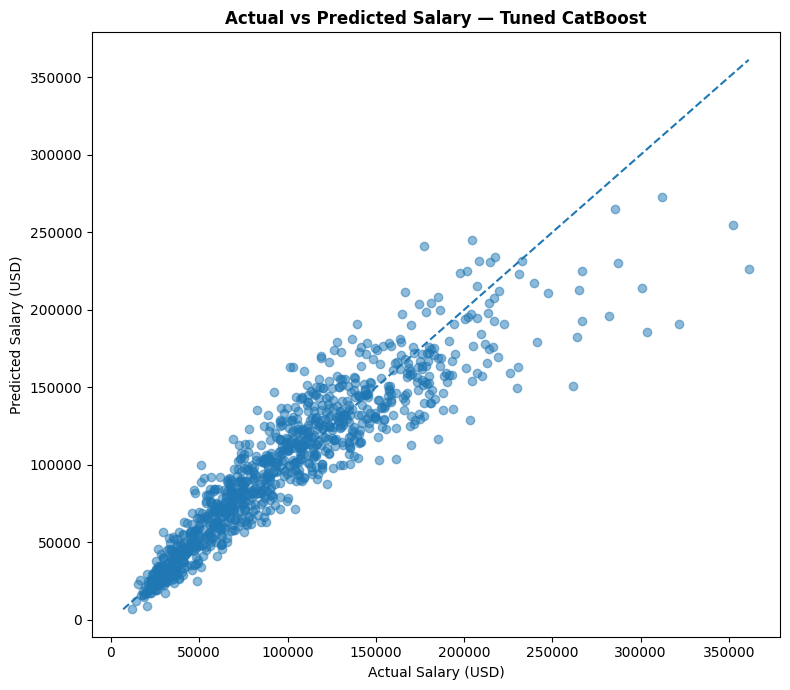

In [145]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.5
)

# Perfect prediction line
min_salary = min(y_test.min(), final_predictions.min())
max_salary = max(y_test.max(), final_predictions.max())

plt.plot(
    [min_salary, max_salary],
    [min_salary, max_salary],
    linestyle='--'
)

plt.xlabel('Actual Salary (USD)')
plt.ylabel('Predicted Salary (USD)')
plt.title(
    f'Actual vs Predicted Salary — {best_tuned_name}',
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### 10.2 Calculate Residuals

In [146]:
prediction_df['Residual'] = (
    prediction_df['Actual Salary']
    - prediction_df['Predicted Salary']
)

prediction_df.head(10)

,Actual Salary,Predicted Salary,Residual
0,36976,36231.506830,744.493170
1,65737,83211.941063,-17474.941063
2,31555,45333.650097,-13778.650097
3,59230,50287.192353,8942.807647
4,34279,40683.019574,-6404.019574
5,135891,118419.321056,17471.678944
6,111590,101306.489143,10283.510857
7,129256,150096.127577,-20840.127577
8,69595,70549.001676,-954.001676
9,174989,129672.486939,45316.513061


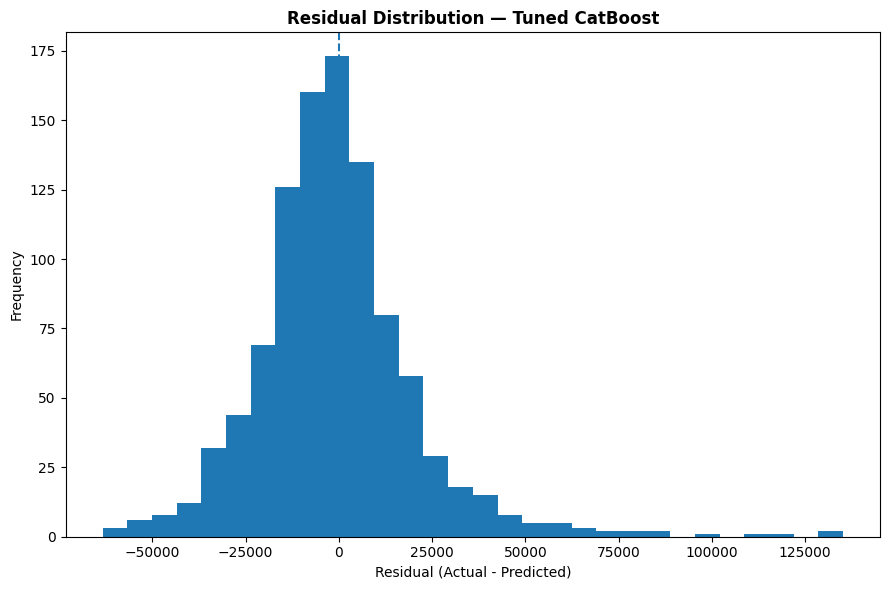

In [147]:
# Residual Distribution

plt.figure(figsize=(9, 6))

plt.hist(
    prediction_df['Residual'],
    bins=30
)

plt.axvline(
    0,
    linestyle='--'
)

plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title(
    f'Residual Distribution — {best_tuned_name}',
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### 10.3 Residual vs Predicted Values

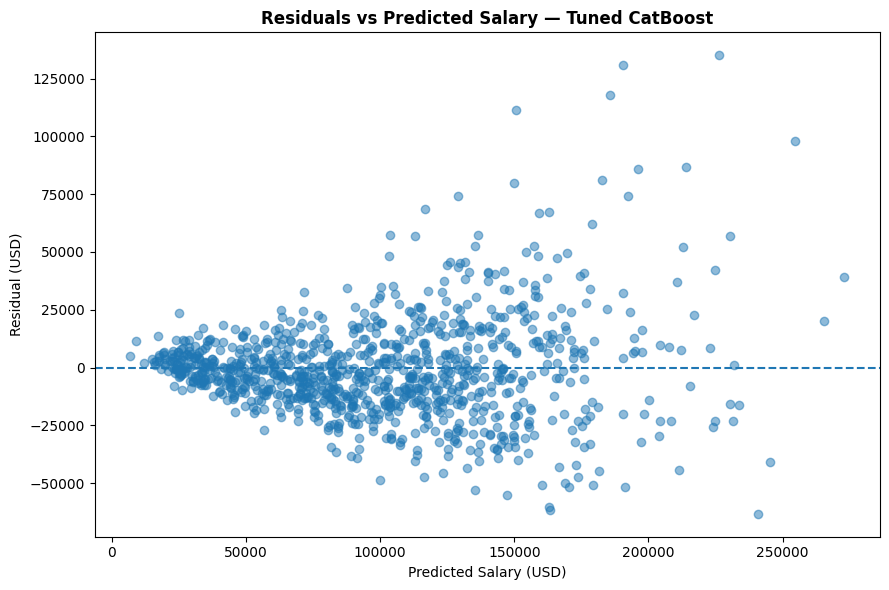

In [148]:
plt.figure(figsize=(9, 6))

plt.scatter(
    prediction_df['Predicted Salary'],
    prediction_df['Residual'],
    alpha=0.5
)

plt.axhline(
    0,
    linestyle='--'
)

plt.xlabel('Predicted Salary (USD)')
plt.ylabel('Residual (USD)')
plt.title(
    f'Residuals vs Predicted Salary — {best_tuned_name}',
    fontweight='bold'
)

plt.tight_layout()
plt.show()